**Fourier Feature Network using DeepXDE module**

In [1]:
import os
os.environ["DDE_BACKEND"] = "tensorflow.compat.v1"

import deepxde as dde


Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.



Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
# import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split
import tensorflow as tf
# from torch.optim.lr_scheduler import ReduceLROnPlateau

Data loading

In [ ]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_multinoise.h5", 'r')
print(list(datastore.keys()))
data_I_clean = np.array(np.array(datastore["I_clean"]))
alpha_list = [0.1, 0.2, 0.3, 0.4, 0.5]
sigma_list = [5, 7, 9, 11]
data_I_noisy = np.array(datastore["I_large"])

data_c = np.array(np.array(datastore["c"]))
data_h = np.array(np.array(datastore["h"]))
data_p = np.array(np.array(datastore["parameters: J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts"]))
t = np.linspace(0, 1, 601).reshape(601, 1)
datastore.close()

['I_clean', 'I_large', 'c', 'f', 'h', 'parameters: J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts']


Train-test split

In [5]:
train_label, test_label = train_test_split(range(len(data_I_clean)), test_size=0.5, random_state=42)

data_i_clean_train = data_I_clean[train_label,:]
data_i_clean_test = data_I_clean[test_label,:]

data_c_train = data_c[train_label,:]
data_c_test = data_c[test_label,:]

data_h_train = data_h[train_label,:]
data_h_test = data_h[test_label,:]

In [6]:
data_I_noisy_train = []
data_I_noisy_test = []

for i in range(len(data_I_noisy)):
    if i%len(data_I_clean) in train_label:
        data_I_noisy_train.append(data_I_noisy[i])
    else:
        data_I_noisy_test.append(data_I_noisy[i])
        
data_I_noisy_train = np.array(data_I_noisy_train)
data_I_noisy_test = np.array(data_I_noisy_test)

data_c_train_large = np.vstack([data_c_train]*4)
data_c_test_large = np.vstack([data_c_test]*4)
data_h_train_large = np.vstack([data_h_train]*4)
data_h_test_large = np.vstack([data_h_test]*4)


In [7]:
X_clean_train = data_i_clean_train.astype(np.float32)
X_noisy_train = data_I_noisy_train.astype(np.float32)
y_train_c = data_c_train.astype(np.float32)
y_train_c_large = data_c_train_large.astype(np.float32)

In [8]:
X_clean_test = data_i_clean_test.astype(np.float32)
X_noisy_test = data_I_noisy_test.astype(np.float32)
y_test_c = data_c_test.astype(np.float32)
y_test_c_large = data_c_test_large.astype(np.float32)

In [9]:
def custom_loss(y_true, y_pred):
   
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    

    d1 = y_pred[:, 1:] - y_pred[:, :-1]
    
    return mse + 1.6 * tf.reduce_mean(tf.square(d1)) 

In [10]:
data_c_clean = dde.data.dataset.DataSet(
    X_train=X_clean_train, y_train=y_train_c, X_test=X_clean_test, y_test=y_test_c
)

In [11]:
data_c_noisy = dde.data.dataset.DataSet(
    X_train=X_noisy_train, y_train=y_train_c_large, X_test=X_noisy_test, y_test=y_test_c_large
)

In [17]:
m = 601
dim_x = 1

net_c_noisy = dde.nn.MsFFN(
    [m, 300, 200, 200, m],
    "relu",
    "Glorot normal",
    sigmas = [0.5, 1, 2]
)

In [18]:
net_c_clean = dde.nn.MsFFN(
    [m, 300, 200, 200, m],
    "relu",
    "Glorot normal",
    sigmas = [0.5, 1, 2]
)


In [20]:
# def compute_parameters(layers):
#     params = 0
#     for i in range(len(layers) - 1):
#         params += layers[i] * layers[i + 1]  # Weights
#         params += layers[i + 1]             # Biases
#     return params

# branch_layers = [m, 600, 400, 400, m]

# branch_params = compute_parameters(branch_layers)
# total_params = branch_params
# print(f"Total trainable parameters: {total_params}")


In [15]:
model_c_clean = dde.Model(data_c_clean, net_c_clean)
model_c_clean.compile("adam", lr=0.001, loss=custom_loss, metrics=["l2 relative error"])
# losshistory_c_clean, train_state_c_clean = model_c_clean.train(iterations=1000, display_every=100)
path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_clean_ffn2-2000.ckpt'
model_c_clean.restore(path)

Compiling model...
Building Multiscale Fourier Feature Network...

'compile' took 1.054860 s

INFO:tensorflow:Restoring parameters from C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_clean_ffn2-2000.ckpt


In [30]:
model_c_noisy = dde.Model(data_c_noisy, net_c_noisy)
model_c_noisy.compile("adam", lr=0.001, loss=custom_loss, metrics=["l2 relative error"])
losshistory_c_noisy, train_state_c_noisy = model_c_noisy.train(iterations=1000, display_every=100)
# path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_noisy_ffn2-1000.ckpt'
# model_c_noisy.restore(path)

Compiling model...
'compile' took 0.362038 s

Training model...

0         [2.54e+00]    [2.53e+00]    [1.05e+00]    
100       [2.66e-01]    [2.70e-01]    [3.67e-01]    
200       [2.54e-01]    [2.64e-01]    [3.66e-01]    
300       [2.34e-01]    [2.71e-01]    [3.72e-01]    
400       [1.76e-01]    [3.10e-01]    [3.98e-01]    
500       [1.41e-01]    [3.44e-01]    [4.20e-01]    
600       [1.23e-01]    [3.67e-01]    [4.34e-01]    
700       [1.12e-01]    [3.84e-01]    [4.45e-01]    
800       [1.03e-01]    [3.96e-01]    [4.52e-01]    
900       [9.68e-02]    [4.14e-01]    [4.62e-01]    
1000      [9.16e-02]    [4.28e-01]    [4.70e-01]    

Best model at step 1000:
  train loss: 9.16e-02
  test loss: 4.28e-01
  test metric: [4.70e-01]

'train' took 1239.216307 s



In [16]:
# losshistory_c, train_state_c = model_c.train(iterations=500, display_every=100)

In [23]:
y_train_h = data_h_train.astype(np.float32)
y_test_h = data_h_test.astype(np.float32)

y_train_h_large = data_h_train_large.astype(np.float32)
y_test_h_large = data_h_test_large.astype(np.float32)

In [24]:
data_h_clean = dde.data.dataset.DataSet(
    X_train=X_clean_train, y_train=y_train_h, X_test=X_clean_test, y_test=y_test_h
)

In [25]:
data_h_noisy = dde.data.dataset.DataSet(
    X_train=X_noisy_train, y_train=y_train_h_large, X_test=X_noisy_test, y_test=y_test_h_large
)

In [22]:
m = 601
dim_x = 1
net_h_clean = dde.nn.MsFFN(
    [m, 300, 200, 200, m],
    "relu",
    "Glorot normal",
    sigmas = [0.5, 1, 2]
)

net_h_noisy = dde.nn.MsFFN(
    [m, 300, 200, 200, m],
    "relu",
    "Glorot normal",
    sigmas = [0.5, 1, 2]
)

In [34]:
model_h_clean = dde.Model(data_h_clean, net_h_clean)
model_h_clean.compile("adam", lr=0.001, loss=custom_loss, metrics=["l2 relative error"])
losshistory_h_clean, train_state_h_clean = model_h_clean.train(iterations=1000, display_every=100)
# path = 'C:/Users/arnab/OneD/rive/Desktop/Study material/summer 24/Research/New equations/models/model_h_clean_ffn2-1000.ckpt'
# model_h_clean.restore(path)

Compiling model...
'compile' took 0.437234 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [1.06e+00]    [1.06e+00]    [1.17e+00]    
100       [2.89e-03]    [2.91e-03]    [5.68e-02]    
200       [1.29e-03]    [1.33e-03]    [4.26e-02]    
300       [8.56e-04]    [9.02e-04]    [3.67e-02]    
400       [6.36e-04]    [6.90e-04]    [3.30e-02]    
500       [5.27e-04]    [5.85e-04]    [3.10e-02]    
600       [4.82e-04]    [5.43e-04]    [3.05e-02]    
700       [4.14e-04]    [4.77e-04]    [2.88e-02]    
800       [3.79e-04]    [4.43e-04]    [2.80e-02]    
900       [3.50e-04]    [4.15e-04]    [2.73e-02]    
1000      [3.32e-04]    [3.96e-04]    [2.69e-02]    

Best model at step 1000:
  train loss: 3.32e-04
  test loss: 3.96e-04
  test metric: [2.69e-02]

'train' took 285.408856 s



In [31]:
model_h_noisy = dde.Model(data_h_noisy, net_h_noisy)
model_h_noisy.compile("adam", lr=0.001, loss=custom_loss, metrics=["l2 relative error"])
losshistory_h_noisy, train_state_h_noisy = model_h_noisy.train(iterations=1000, display_every=100)
# path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_noisy_ffn2-1000.ckpt'
# model_h_noisy.restore(path)

Compiling model...
'compile' took 0.489768 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [1.02e+00]    [1.02e+00]    [1.16e+00]    
100       [2.12e-02]    [2.11e-02]    [2.05e-01]    
200       [1.94e-02]    [1.94e-02]    [2.03e-01]    
300       [1.88e-02]    [1.90e-02]    [2.02e-01]    
400       [1.83e-02]    [1.88e-02]    [2.02e-01]    
500       [1.78e-02]    [1.88e-02]    [2.03e-01]    
600       [1.70e-02]    [1.90e-02]    [2.05e-01]    
700       [1.57e-02]    [1.98e-02]    [2.09e-01]    
800       [1.40e-02]    [2.11e-02]    [2.16e-01]    
900       [1.26e-02]    [2.25e-02]    [2.24e-01]    
1000      [1.15e-02]    [2.39e-02]    [2.30e-01]    

Best model at step 1000:
  train loss: 1.15e-02
  test loss: 2.39e-02
  test metric: [2.30e-01]

'train' took 1162.858309 s



In [23]:
# losshistory_h, train_state_h = model_h.train(iterations=500, display_every=100)

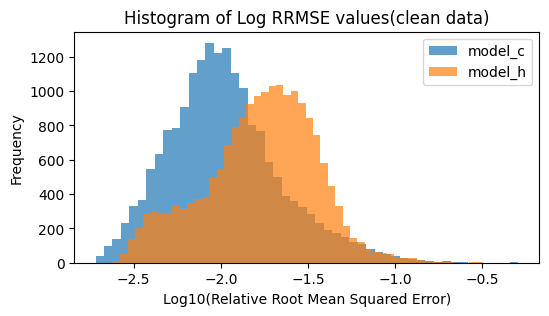

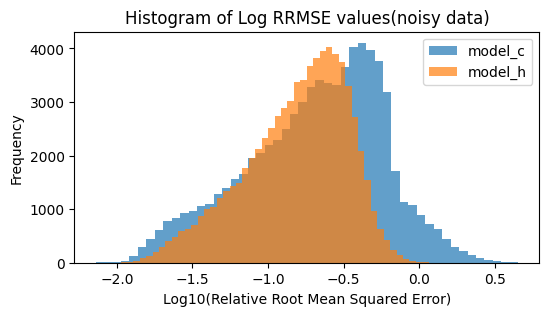

In [35]:
# Use trained model to make predictions
predictions_c_clean = model_c_clean.predict(data_i_clean_test)  # Ensure model_c is defined
predictions_h_clean = model_h_clean.predict(data_i_clean_test)  # Ensure model_h is defined
predictions_c_noisy = model_c_noisy.predict(data_I_noisy_test)  # Ensure model_c is defined
predictions_h_noisy = model_h_noisy.predict(data_I_noisy_test)  # Ensure model_h is defined

# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_clean = np.sqrt(np.sum((predictions_c_clean - data_c_test) ** 2, axis=1) / np.sum((data_c_test ** 2), axis=1))
rrmse_h_clean = np.sqrt(np.sum((predictions_h_clean - data_h_test) ** 2, axis=1) / np.sum((data_h_test ** 2), axis=1))

rrmse_c_noisy = np.sqrt(np.sum((predictions_c_noisy - data_c_test_large) ** 2, axis=1) / np.sum(data_c_test_large ** 2, axis=1))
rrmse_h_noisy = np.sqrt(np.sum((predictions_h_noisy - data_h_test_large) ** 2, axis=1) / np.sum(data_h_test_large ** 2, axis=1))

# Log-scale histogram
plt.figure(figsize=(6, 3))
plt.hist(np.log10(rrmse_c_clean), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_clean), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values(clean data)')
plt.legend()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_FFN_clean_synthetic.png", bbox_inches="tight", pad_inches=0.1)
plt.show()

plt.figure(figsize=(6,3))
plt.hist(np.log10(rrmse_c_noisy), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_noisy), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values(noisy data)')
plt.legend()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_FFN_noisy_synthetic.png", bbox_inches="tight", pad_inches=0.1)
plt.show()


5764
J_e: 0.3307247580385323
b_1: 3.3527574941490172
b_2: 9.585858357981241
h_e: 0.0
f_0: 0.8047290553495486
P_c: 0.19080769516294824
phi: 0.72497655949243
ts_halton: 22.743668718716116
h_0: 7.788319610547249e-06


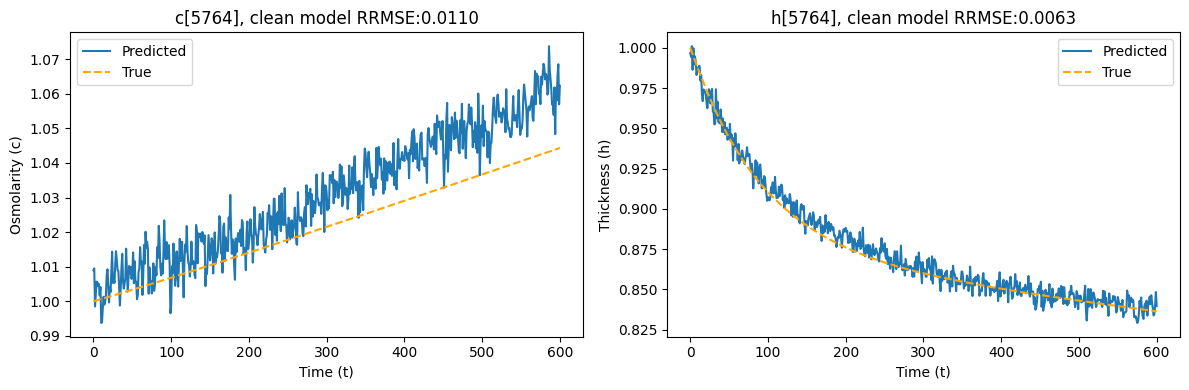

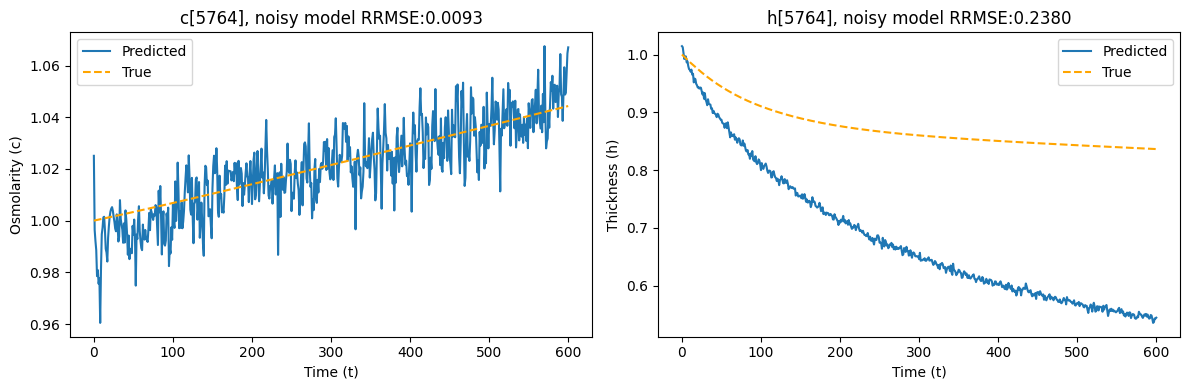

In [36]:
n = np.random.randint(0, len(data_I_noisy_test))
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n%len(data_i_clean_test)]

print(n)
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")
pred_c_clean = model_c_clean.predict(data_i_clean_test[n%len(data_i_clean_test)].reshape(1, -1))
pred_h_clean = model_h_clean.predict(data_i_clean_test[n%len(data_i_clean_test)].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c_clean.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title(f'c[{n}], clean model RRMSE:{rrmse_c_clean[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_clean.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title(f'h[{n}], clean model RRMSE:{rrmse_h_clean[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

pred_c_noisy = model_c_noisy.predict(data_I_noisy_test[n].reshape(1, -1))
pred_h_noisy = model_h_noisy.predict(data_I_noisy_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]

axs[0].plot(pred_c_noisy.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title(f'c[{n}], noisy model RRMSE:{rrmse_c_noisy[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_noisy.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title(f'h[{n}], noisy model RRMSE:{rrmse_h_noisy[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()


**Further inspection**

In [37]:
pred_c_clean = model_c_clean.predict(data_i_clean_test)
error_c_clean = np.sum((data_c_test - pred_c_clean)**2, axis=1)/601
max_error_c = np.max(error_c_clean)
print(max_error_c, np.mean(error_c_clean))
max_error_index_c_clean = np.argmax(error_c_clean)
print("Index of max_error:", max_error_index_c_clean)

1.5982214223321491 0.0013457494197604148
Index of max_error: 14226


In [39]:
pred_h_clean = model_h_clean.predict(data_i_clean_test)
error_h_clean = np.sum((data_h_test - pred_h_clean)**2, axis=1)/601
max_error_h_clean = np.max(error_h_clean)
print(max_error_h_clean, np.mean(error_h_clean))
max_error_index_h_clean = np.argmax(error_h_clean)
print("Index of max_error:", max_error_index_h_clean)

0.053155828836491864 0.0003229253114540676
Index of max_error: 15904


14226
J_e: 0.6483588736580684
b_1: 4.960585688093296
b_2: 13.204590092785658
h_e: 0.0
f_0: 0.5915423729298087
P_c: 0.18046676619218688
phi: 0.5970828664434188
ts_halton: 17.716279192348928
h_0: 6.4143759366493e-06


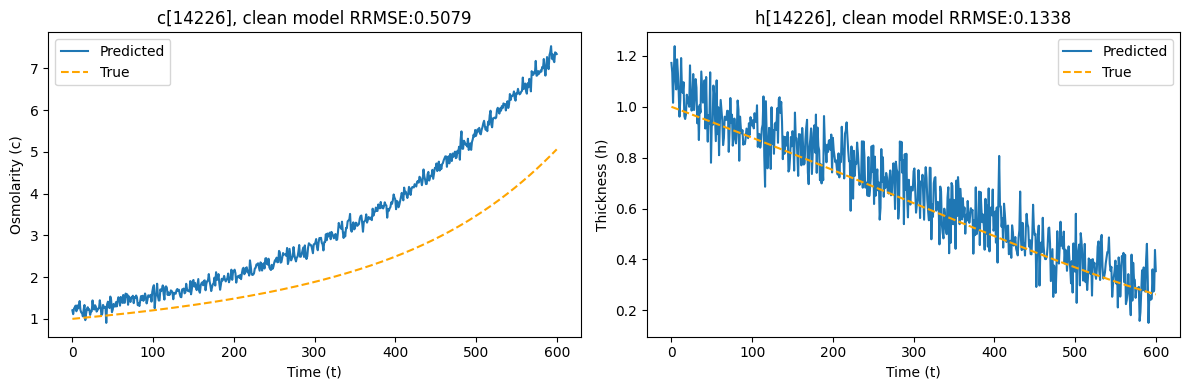

NameError: name 'data_i_noisy_test' is not defined

In [40]:
n = max_error_index_c_clean
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]

print(n)
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")
pred_c_clean = model_c_clean.predict(data_i_clean_test[n].reshape(1, -1))
pred_h_clean = model_h_clean.predict(data_i_clean_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c_clean.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title(f'c[{n}], clean model RRMSE:{rrmse_c_clean[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_clean.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title(f'h[{n}], clean model RRMSE:{rrmse_h_clean[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

pred_c_noisy = model_c_noisy.predict(data_i_noisy_test[n].reshape(1, -1))
pred_h_noisy = model_h_noisy.predict(data_i_noisy_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]

axs[0].plot(pred_c_noisy.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title(f'c[{n}], noisy model RRMSE:{rrmse_c_clean[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_noisy.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title(f'h[{n}], noisy model RRMSE:{rrmse_c_clean[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns
# Plot data_c[n]
axs[0].plot(predictions_c_combined_clean[n].T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')
axs[0].set_title(f'c[{n}], combined clean model RRMSE:{rrmse_c_combined_clean[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(predictions_h_combined_clean[n].T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')
axs[1].set_title(f'h[{n}], combined clean model RRMSE:{rrmse_h_combined_clean[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
# Plot data_c[n]
axs[0].plot(predictions_c_combined_noisy[n].T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')
axs[0].set_title(f'c[{n}], combined noisy model RRMSE:{rrmse_c_combined_noisy[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(predictions_h_combined_noisy[n].T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')
axs[1].set_title(f'h[{n}], combined noisy model RRMSE:{rrmse_h_combined_noisy[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()


5206
J_e: 0.040459427530907095
b_1: 0.8243222354384564
b_2: 42.7646051924753
h_e: 0.0
f_0: 0.7516440312524463
P_c: 0.24986958539486057
phi: 0.6620969387807456
ts_halton: 27.200422288563594
h_0: 7.112812828044581e-06


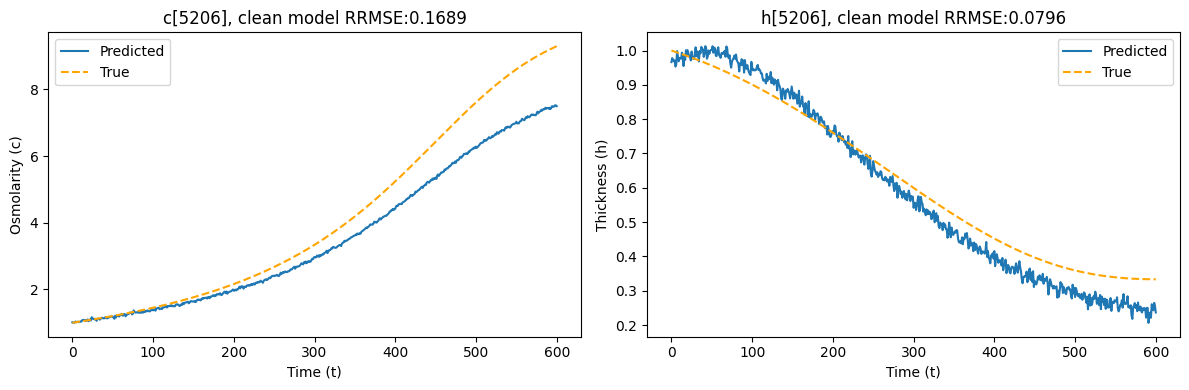

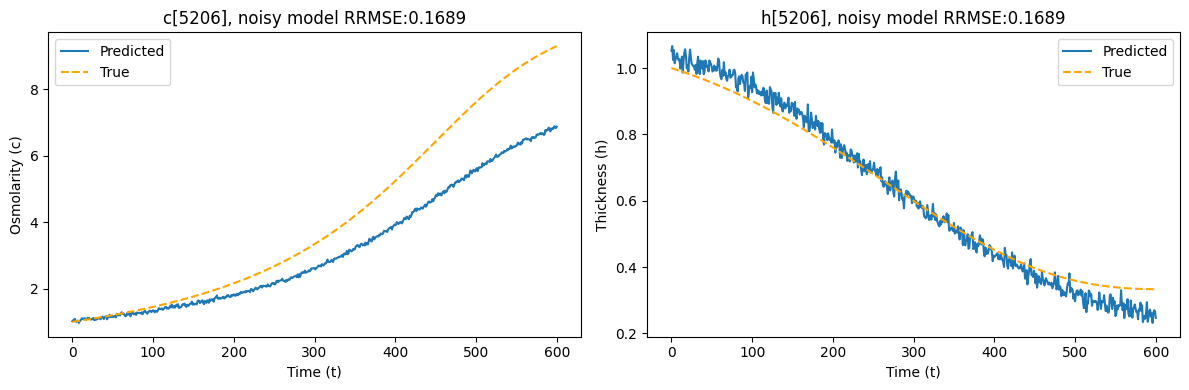

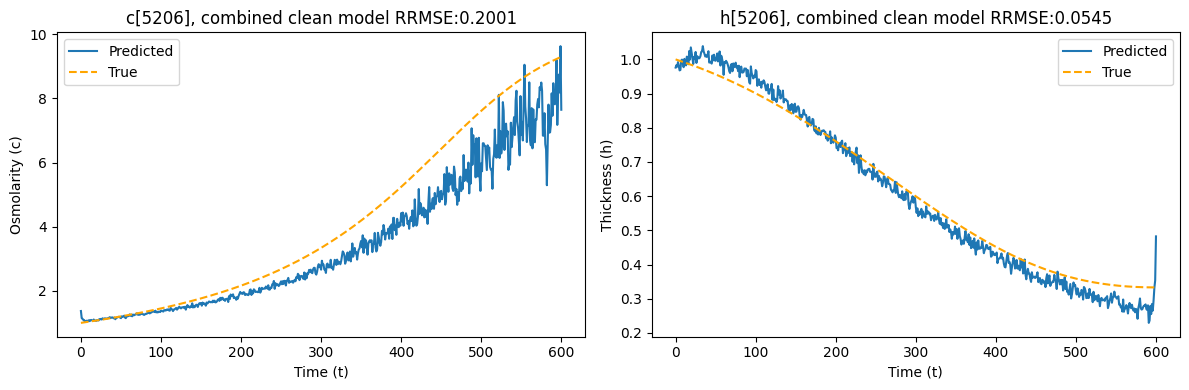

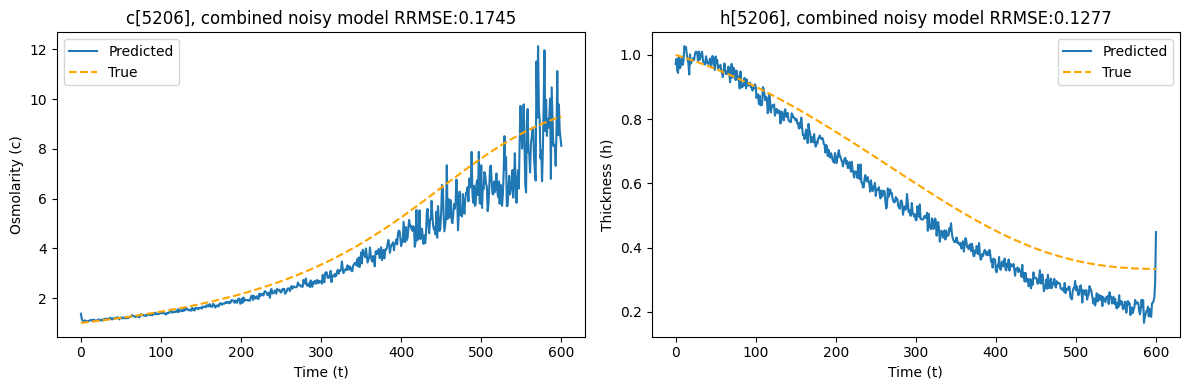

In [82]:
n = max_error_index_c_noisy
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]

print(n)
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")
pred_c_clean = model_c_clean.predict(data_i_clean_test[n].reshape(1, -1))
pred_h_clean = model_h_clean.predict(data_i_clean_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c_clean.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title(f'c[{n}], clean model RRMSE:{rrmse_c_clean[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_clean.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title(f'h[{n}], clean model RRMSE:{rrmse_h_clean[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

pred_c_noisy = model_c_noisy.predict(data_i_noisy_test[n].reshape(1, -1))
pred_h_noisy = model_h_noisy.predict(data_i_noisy_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]

axs[0].plot(pred_c_noisy.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title(f'c[{n}], noisy model RRMSE:{rrmse_c_clean[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_noisy.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title(f'h[{n}], noisy model RRMSE:{rrmse_c_clean[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns
# Plot data_c[n]
axs[0].plot(predictions_c_combined_clean[n].T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')
axs[0].set_title(f'c[{n}], combined clean model RRMSE:{rrmse_c_combined_clean[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(predictions_h_combined_clean[n].T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')
axs[1].set_title(f'h[{n}], combined clean model RRMSE:{rrmse_h_combined_clean[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
# Plot data_c[n]
axs[0].plot(predictions_c_combined_noisy[n].T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')
axs[0].set_title(f'c[{n}], combined noisy model RRMSE:{rrmse_c_combined_noisy[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(predictions_h_combined_noisy[n].T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')
axs[1].set_title(f'h[{n}], combined noisy model RRMSE:{rrmse_h_combined_noisy[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()


7038
J_e: 0.03986273887817137
b_1: 2.1653005208587603
b_2: 3.3966615258613393
h_e: 0.0
f_0: 0.9329919390119682
P_c: 0.02117912563443224
phi: 0.5802342556791167
ts_halton: 2.020468397660332
h_0: 6.233373718152796e-06


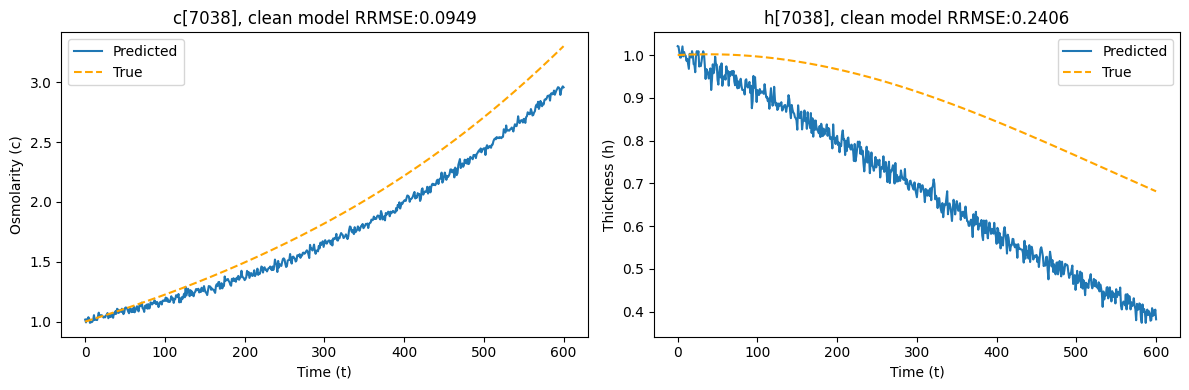

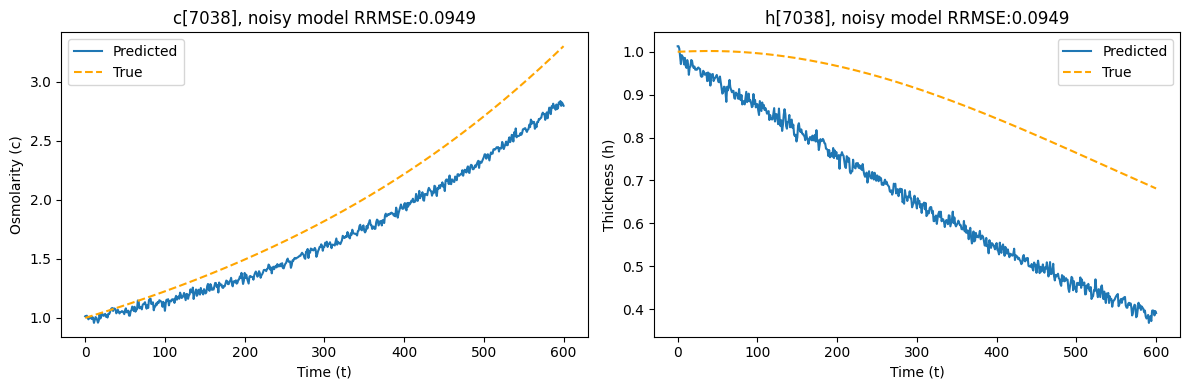

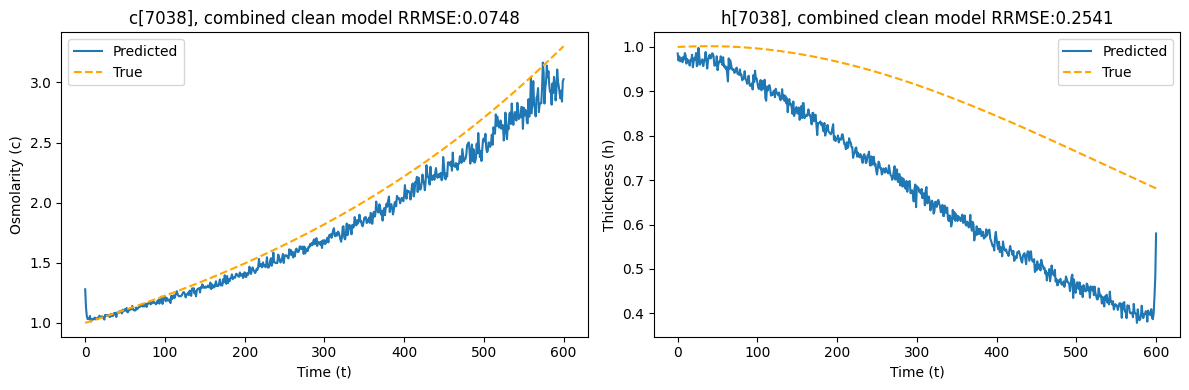

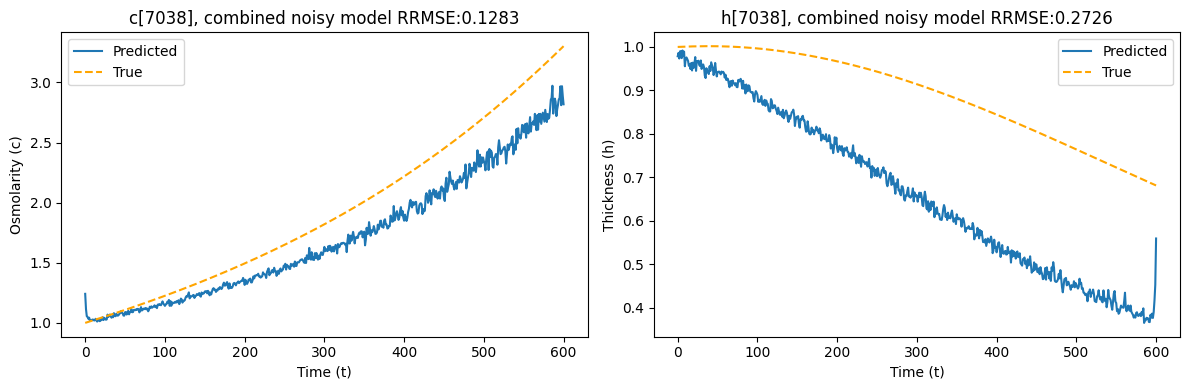

In [83]:
n = max_error_index_h_clean
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]

print(n)
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")
pred_c_clean = model_c_clean.predict(data_i_clean_test[n].reshape(1, -1))
pred_h_clean = model_h_clean.predict(data_i_clean_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c_clean.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title(f'c[{n}], clean model RRMSE:{rrmse_c_clean[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_clean.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title(f'h[{n}], clean model RRMSE:{rrmse_h_clean[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

pred_c_noisy = model_c_noisy.predict(data_i_noisy_test[n].reshape(1, -1))
pred_h_noisy = model_h_noisy.predict(data_i_noisy_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]

axs[0].plot(pred_c_noisy.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title(f'c[{n}], noisy model RRMSE:{rrmse_c_clean[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_noisy.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title(f'h[{n}], noisy model RRMSE:{rrmse_c_clean[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns
# Plot data_c[n]
axs[0].plot(predictions_c_combined_clean[n].T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')
axs[0].set_title(f'c[{n}], combined clean model RRMSE:{rrmse_c_combined_clean[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(predictions_h_combined_clean[n].T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')
axs[1].set_title(f'h[{n}], combined clean model RRMSE:{rrmse_h_combined_clean[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
# Plot data_c[n]
axs[0].plot(predictions_c_combined_noisy[n].T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')
axs[0].set_title(f'c[{n}], combined noisy model RRMSE:{rrmse_c_combined_noisy[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(predictions_h_combined_noisy[n].T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')
axs[1].set_title(f'h[{n}], combined noisy model RRMSE:{rrmse_h_combined_noisy[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()


15904
J_e: 0.03243130912976278
b_1: 1.3887030003966676
b_2: 3.3665904208817965
h_e: 0.0
f_0: 0.8820576222853369
P_c: 0.05426449989651217
phi: 0.2584743433380137
ts_halton: 2.306077593017219
h_0: 2.7767529455740903e-06


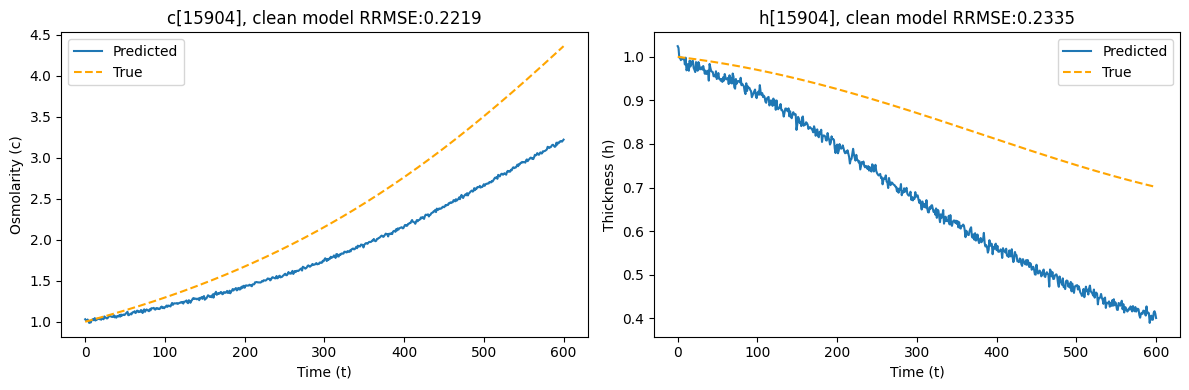

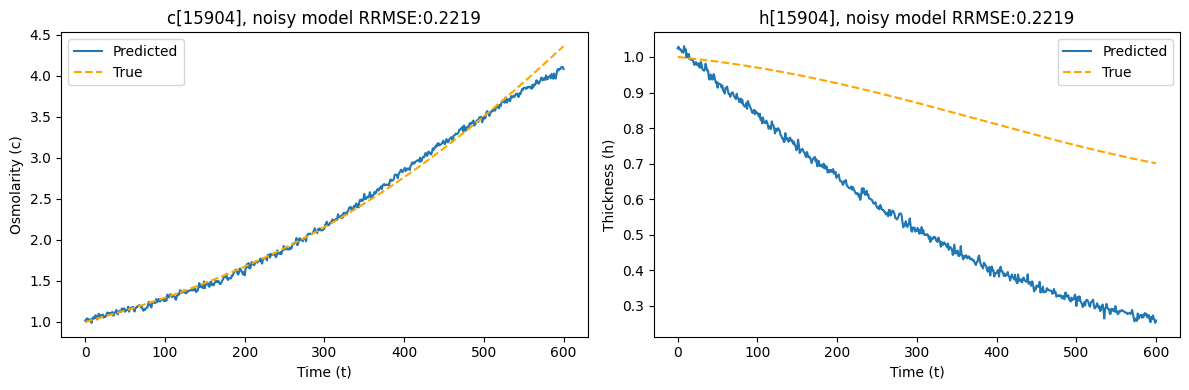

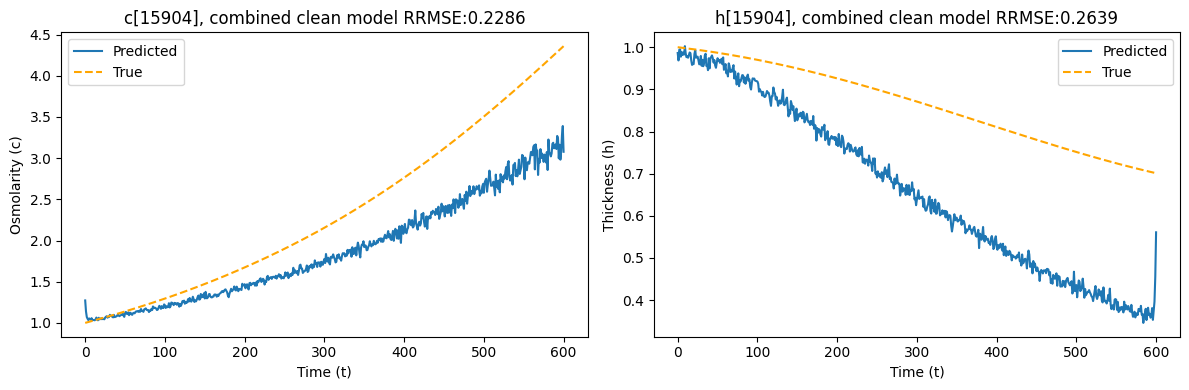

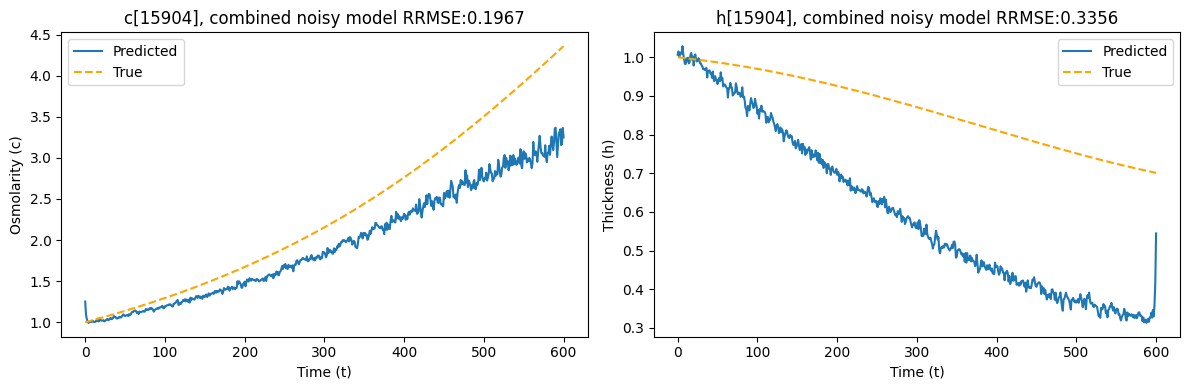

In [84]:
n = max_error_index_h_noisy
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]

print(n)
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")
pred_c_clean = model_c_clean.predict(data_i_clean_test[n].reshape(1, -1))
pred_h_clean = model_h_clean.predict(data_i_clean_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c_clean.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title(f'c[{n}], clean model RRMSE:{rrmse_c_clean[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_clean.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title(f'h[{n}], clean model RRMSE:{rrmse_h_clean[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

pred_c_noisy = model_c_noisy.predict(data_i_noisy_test[n].reshape(1, -1))
pred_h_noisy = model_h_noisy.predict(data_i_noisy_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]

axs[0].plot(pred_c_noisy.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title(f'c[{n}], noisy model RRMSE:{rrmse_c_clean[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_noisy.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title(f'h[{n}], noisy model RRMSE:{rrmse_c_clean[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns
# Plot data_c[n]
axs[0].plot(predictions_c_combined_clean[n].T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')
axs[0].set_title(f'c[{n}], combined clean model RRMSE:{rrmse_c_combined_clean[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(predictions_h_combined_clean[n].T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')
axs[1].set_title(f'h[{n}], combined clean model RRMSE:{rrmse_h_combined_clean[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
# Plot data_c[n]
axs[0].plot(predictions_c_combined_noisy[n].T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')
axs[0].set_title(f'c[{n}], combined noisy model RRMSE:{rrmse_c_combined_noisy[n]:.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(predictions_h_combined_noisy[n].T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')
axs[1].set_title(f'h[{n}], combined noisy model RRMSE:{rrmse_h_combined_noisy[n]:.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()


In [85]:
datastore_glob = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/PDE_1d_glob_new_center_filtered.jld2", 'r')
data_I_glob = np.array(np.array(datastore_glob["filtered_data_I"]))

data_c_glob = np.array(np.array(datastore_glob["filtered_data_c"]))
data_h_glob = np.array(np.array(datastore_glob["filtered_data_h"]))

data_p_glob = np.array(np.array(datastore_glob["filtered_para"]))
data_ts_glob = data_p_glob[:,0].reshape(-1, 1)
data_h0_glob = data_p_glob[:,1].reshape(-1, 1)
data_f0_glob = data_p_glob[:,2].reshape(-1, 1)


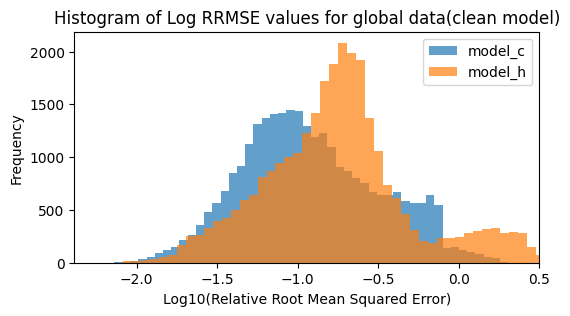

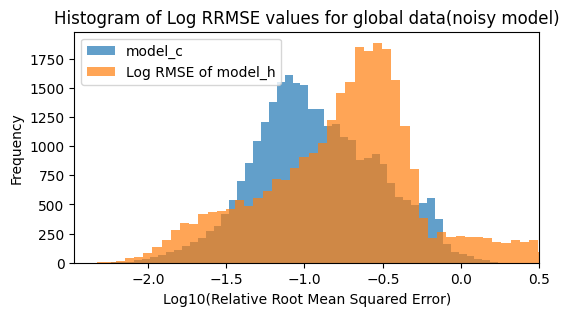

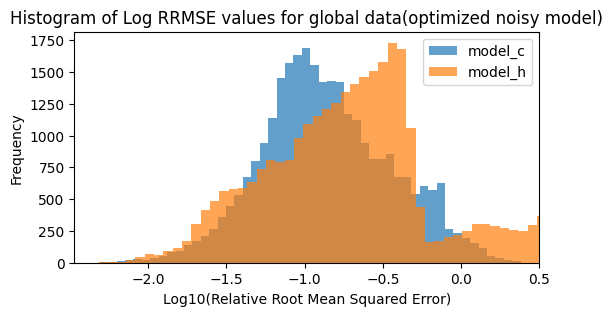

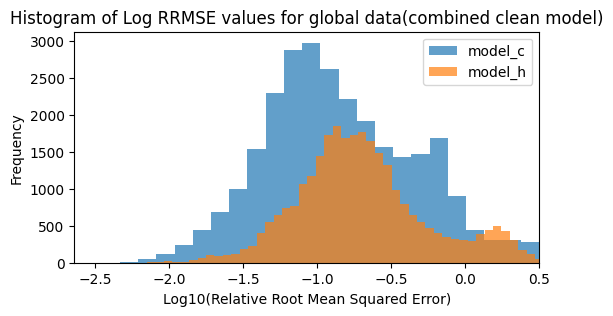

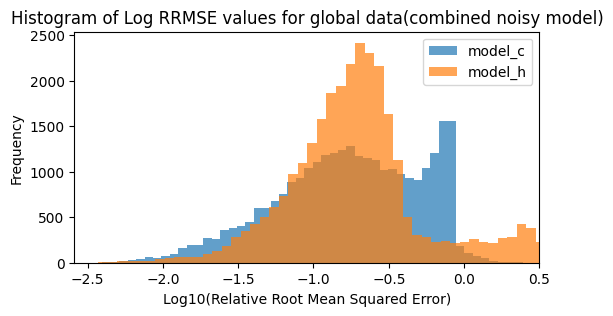

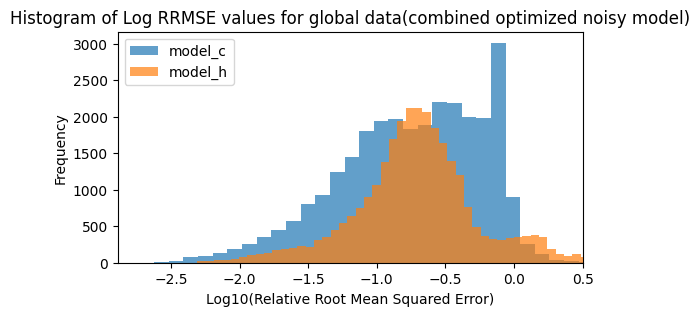

In [120]:
# Prepare the test data
X_test_glob = data_I_glob.astype(np.float32)
y_test_c_glob = data_c_glob.astype(np.float32)
y_test_h_glob = data_h_glob.astype(np.float32)

# Use trained models to make predictions
predictions_c_glob_clean = model_c_clean.predict(X_test_glob)
predictions_h_glob_clean = model_h_clean.predict(X_test_glob)

predictions_c_glob_noisy = model_c_noisy.predict(X_test_glob)
predictions_h_glob_noisy = model_h_noisy.predict(X_test_glob)

predictions_c_glob_noisy_opt = model_c_noisy_opt.predict(X_test_glob)
predictions_h_glob_noisy_opt = model_h_noisy_opt.predict(X_test_glob)

predictions_combined_glob_clean = model_combined_clean.predict(X_test_glob)
predictions_c_combined_glob_clean = 1/(predictions_combined_glob_clean[:, :601]+1e-14)  # Extracting the first 601 columns for c predictions
predictions_h_combined_glob_clean = predictions_combined_glob_clean[:, 601:]  # Extracting the last 601 columns for h predictions

predictions_combined_glob_noisy = model_combined_noisy.predict(X_test_glob)
predictions_c_combined_glob_noisy = 1/(predictions_combined_glob_noisy[:, :601]+1e-14)
predictions_h_combined_glob_noisy = predictions_combined_glob_noisy[:, 601:]  # Extracting the last 601 columns for h predictions

predictions_combined_glob_noisy_opt = model_combined_noisy_opt.predict(X_test_glob)
predictions_c_combined_glob_noisy_opt = 1/(predictions_combined_glob_noisy_opt[:, :601]+1e-14)
predictions_h_combined_glob_noisy_opt = predictions_combined_glob_noisy_opt[:, 601:]  # Extracting the last 601 columns for h predictions

# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_glob_clean = np.sqrt(np.sum((predictions_c_glob_clean - y_test_c_glob) ** 2, axis=1) / np.sum(y_test_c_glob ** 2, axis=1))
rrmse_h_glob_clean = np.sqrt(np.sum((predictions_h_glob_clean - y_test_h_glob) ** 2, axis=1) / np.sum(y_test_h_glob ** 2, axis=1))

rrmse_c_glob_noisy = np.sqrt(np.sum((predictions_c_glob_noisy - y_test_c_glob) ** 2, axis=1) / np.sum(y_test_c_glob ** 2, axis=1))
rrmse_h_glob_noisy = np.sqrt(np.sum((predictions_h_glob_noisy - y_test_h_glob) ** 2, axis=1) / np.sum(y_test_h_glob ** 2, axis=1))

rrmse_c_glob_noisy_opt = np.sqrt(np.sum((predictions_c_glob_noisy_opt - y_test_c_glob) ** 2, axis=1) / np.sum(y_test_c_glob ** 2, axis=1))
rrmse_h_glob_noisy_opt = np.sqrt(np.sum((predictions_h_glob_noisy_opt - y_test_h_glob) ** 2, axis=1) / np.sum(y_test_h_glob ** 2, axis=1))

rrmse_c_combined_glob_clean = np.sqrt(np.sum((predictions_c_combined_glob_clean - y_test_c_glob) ** 2, axis=1) / np.sum(y_test_c_glob ** 2, axis=1))
rrmse_h_combined_glob_clean = np.sqrt(np.sum((predictions_h_combined_glob_clean - y_test_h_glob) ** 2, axis=1) / np.sum(y_test_h_glob ** 2, axis=1))

rrmse_c_combined_glob_noisy = np.sqrt(np.sum((predictions_c_combined_glob_noisy - y_test_c_glob) ** 2, axis=1) / np.sum(y_test_c_glob ** 2, axis=1))
rrmse_h_combined_glob_noisy = np.sqrt(np.sum((predictions_h_combined_glob_noisy - y_test_h_glob) ** 2, axis=1) / np.sum(y_test_h_glob ** 2, axis=1))

rrmse_c_combined_glob_noisy_opt = np.sqrt(np.sum((predictions_c_combined_glob_noisy_opt - y_test_c_glob) ** 2, axis=1) / np.sum(y_test_c_glob ** 2, axis=1))
rrmse_h_combined_glob_noisy_opt = np.sqrt(np.sum((predictions_h_combined_glob_noisy_opt - y_test_h_glob) ** 2, axis=1) / np.sum(y_test_h_glob ** 2, axis=1))


# Log-scale histogram
plt.figure(figsize=(6,3))
plt.hist(np.log10(rrmse_c_glob_clean), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_glob_clean), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values for global data(clean model)')
plt.legend()
plt.xlim(left=None, right=0.5)  # Set the x-axis limit to not go beyond 0.5
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_glob_clean.png", dpi=300)
plt.show()

plt.figure(figsize=(6,3))
plt.hist(np.log10(rrmse_c_glob_noisy), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_glob_noisy), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values for global data(noisy model)')
plt.legend()
plt.xlim(left=None, right=0.5)  # Set the x-axis limit to not go beyond 0.5
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_glob_noisy.png", dpi=300)
plt.show()

plt.figure(figsize=(6,3))
plt.hist(np.log10(rrmse_c_glob_noisy_opt), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_glob_noisy_opt), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values for global data(optimized noisy model)')
plt.legend()
plt.xlim(left=None, right=0.5)  # Set the x-axis limit to not go beyond 0.5
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_glob_noisy_opt.png", dpi=300)
plt.show()

plt.figure(figsize=(6,3))
plt.hist(np.log10(rrmse_c_combined_glob_clean), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_combined_glob_clean), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values for global data(combined clean model)')
plt.legend()
plt.xlim(left=None, right=0.5)  # Set the x-axis limit to not go beyond 0.5
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_combined_glob_clean.png", dpi=300)
plt.show()

plt.figure(figsize=(6,3))
plt.hist(np.log10(rrmse_c_combined_glob_noisy), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_combined_glob_noisy), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values for global data(combined noisy model)')
plt.legend()
plt.xlim(left=None, right=0.5)  # Set the x-axis limit to not go beyond 0.5
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_combined_glob_noisy.png", dpi=300)
plt.show()

plt.figure(figsize=(6,3))
plt.hist(np.log10(rrmse_c_combined_glob_noisy_opt), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_combined_glob_noisy_opt), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values for global data(combined optimized noisy model)')
plt.legend()
plt.xlim(left=None, right=0.5)  # Set the x-axis limit to not go beyond 0.5
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_combined_glob_noisy_opt.png", dpi=300)
plt.show()

10800


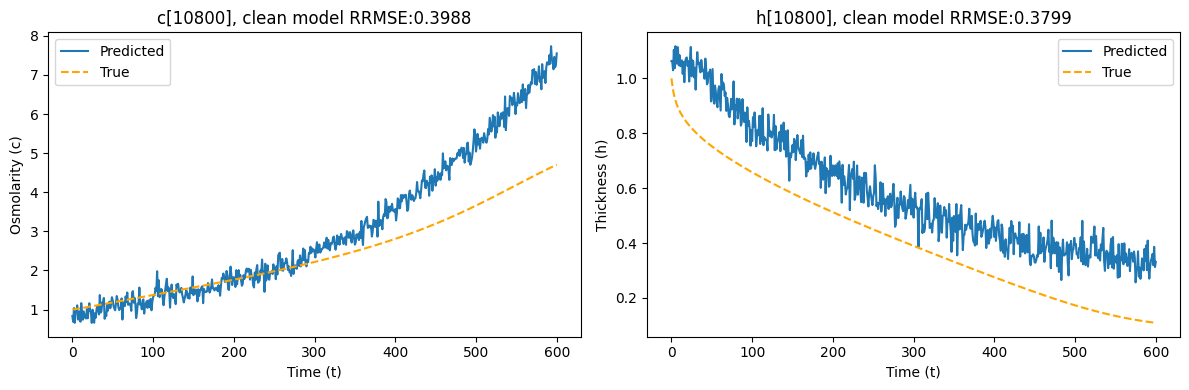

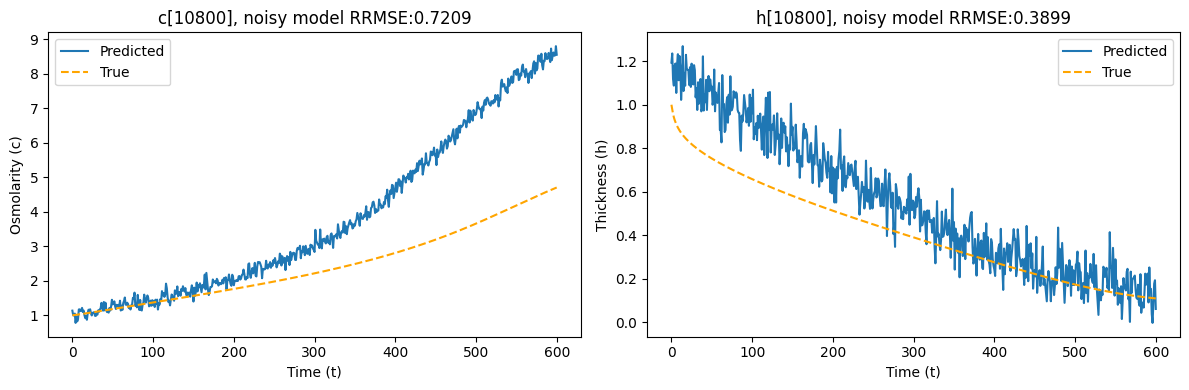

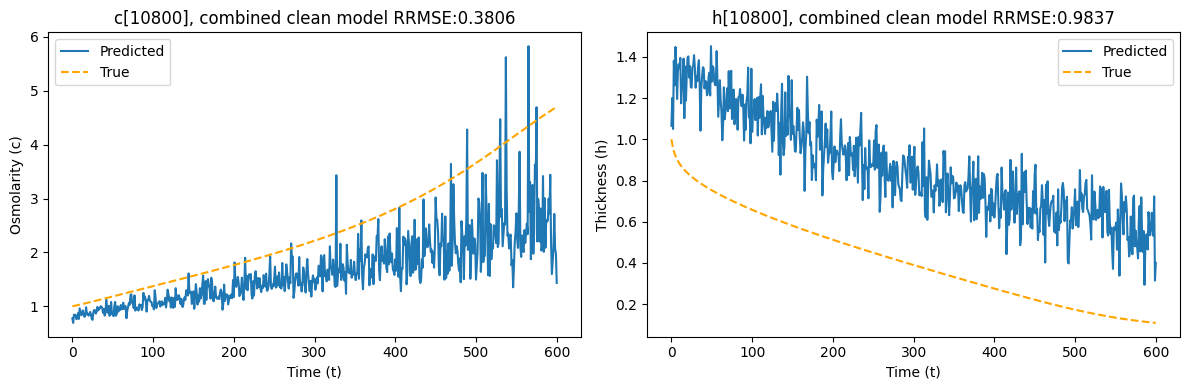

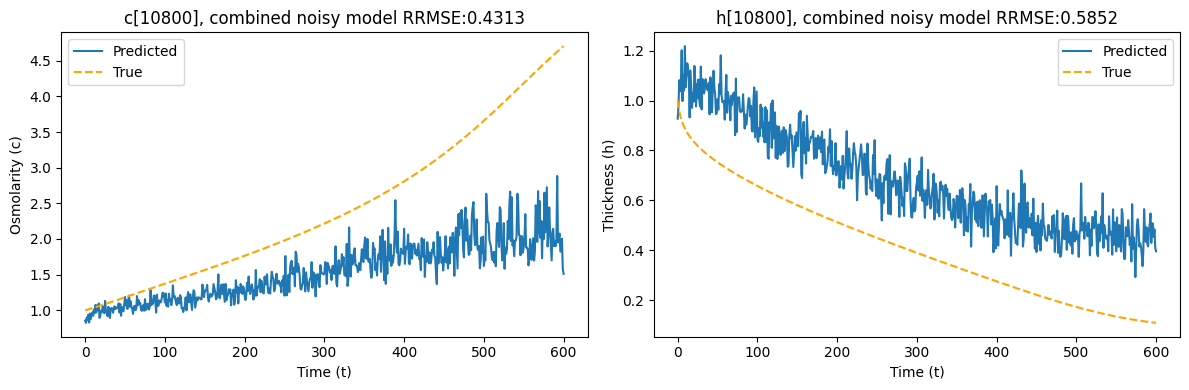

In [123]:
n = np.random.randint(0, len(data_h_glob))
print(n)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(predictions_c_glob_clean[n].T)
axs[0].plot(data_c_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title(f'c[{n}], clean model RRMSE:{np.sqrt(np.sum((predictions_c_glob_clean[n] - data_c_glob[n]) ** 2) / np.sum(data_c_glob[n] ** 2)):.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_clean.T)
axs[1].plot(data_h_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title(f'h[{n}], clean model RRMSE:{np.sqrt(np.sum((pred_h_clean - data_h_glob[n]) ** 2) / np.sum(data_h_glob[n] ** 2)):.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

pred_c_noisy = model_c_noisy.predict(data_I_glob[n].reshape(1, -1))
pred_h_noisy = model_h_noisy.predict(data_I_glob[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]

axs[0].plot(pred_c_noisy.T)
axs[0].plot(data_c_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title(f'c[{n}], noisy model RRMSE:{np.sqrt(np.sum((pred_c_noisy - data_c_glob[n]) ** 2) / np.sum(data_c_glob[n] ** 2)):.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_noisy.T)
axs[1].plot(data_h_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title(f'h[{n}], noisy model RRMSE:{np.sqrt(np.sum((pred_h_noisy - data_h_glob[n]) ** 2) / np.sum(data_h_glob[n] ** 2)):.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

pred_combined_clean = model_combined_clean.predict(data_I_glob[n].reshape(1, -1))
pred_c_inverse_clean = pred_combined_clean[:, :601]  # Extracting the first 601 columns for c predictions
pred_c_combined_clean = 1/(pred_c_inverse_clean + 1e-14)  # Inverting the predictions for c
pred_h_combined_clean = pred_combined_clean[:, 601:]  # Extracting the last 601 columns for h predictions
pred_combined_noisy = model_combined_noisy.predict(data_I_glob[n].reshape(1, -1))
pred_c_inverse_noisy = pred_combined_noisy[:, :601]  # Extracting the first 601 columns for c predictions
pred_c_combined_noisy = 1/(pred_c_inverse_noisy + 1e-14)  # Inverting the predictions for c
pred_h_combined_noisy = pred_combined_noisy[:, 601:]  # Extracting the last 601 columns for h predictions

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns
# Plot data_c[n]
axs[0].plot(pred_c_combined_clean.T)
axs[0].plot(data_c_glob[n], linestyle='--', color='orange')
axs[0].set_title(f'c[{n}], combined clean model RRMSE:{np.sqrt(np.sum((pred_c_combined_clean - data_c_glob[n]) ** 2) / np.sum(data_c_glob[n] ** 2)):.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_combined_clean.T)
axs[1].plot(data_h_glob[n], linestyle='--', color='orange')
axs[1].set_title(f'h[{n}], combined clean model RRMSE:{np.sqrt(np.sum((pred_h_combined_clean - data_h_glob[n]) ** 2) / np.sum(data_h_glob[n] ** 2)):.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
# Plot data_c[n]
axs[0].plot(pred_c_combined_noisy.T)
axs[0].plot(data_c_glob[n], linestyle='--', color='orange')
axs[0].set_title(f'c[{n}], combined noisy model RRMSE:{np.sqrt(np.sum((pred_c_combined_noisy - data_c_glob[n]) ** 2) / np.sum(data_c_glob[n] ** 2)):.4f}')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_combined_noisy.T)
axs[1].plot(data_h_glob[n], linestyle='--', color='orange')
axs[1].set_title(f'h[{n}], combined noisy model RRMSE:{np.sqrt(np.sum((pred_h_combined_noisy - data_h_glob[n]) ** 2) / np.sum(data_h_glob[n] ** 2)):.4f}')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()


In [ ]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_clean_ffn2"
# model_c_clean.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_clean_ffn2-2000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_clean_ffn2-2000.ckpt'

In [ ]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_noisy_ffn2"
# model_c_noisy.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_noisy_ffn2-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_noisy_ffn2-1000.ckpt'

In [ ]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_noisy_opt_ffn2"
# model_c_noisy_opt.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_noisy_opt_ffn2-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_noisy_opt_ffn2-1000.ckpt'

In [ ]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_clean_ffn2"
# model_h_clean.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_clean_ffn2-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_clean_ffn2-1000.ckpt'

In [ ]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_noisy_ffn2"
# model_h_noisy.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_noisy_ffn2-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_noisy_ffn2-1000.ckpt'

In [ ]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_noisy_opt_ffn2"
# model_h_noisy_opt.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_noisy_opt_ffn2-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_noisy_opt_ffn2-1000.ckpt'

In [ ]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_combined_c_clean_ffn2"
# model_combined_clean.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_combined_c_clean_ffn2-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_combined_c_clean_ffn2-1000.ckpt'

In [ ]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_combined_c_noisy_ffn2"
# model_combined_noisy.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_combined_c_noisy_ffn2-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_combined_c_noisy_ffn2-1000.ckpt'

In [ ]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_combined_c_noisy_opt_ffn2"
# model_combined_noisy_opt.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_combined_c_noisy_opt_ffn2-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_combined_c_noisy_opt_ffn2-1000.ckpt'

# Testing the model on experimental data

In [133]:
exprimental_data_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional.txt"
exprimental_data_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional_2.h5"
exprimental_data_nondimensional_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_nondimensional_2.h5"

In [134]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t = h5f['t'][:]
    I = h5f['I'][:]
    p = h5f['p'][:]
    
I_scaled = np.array([row / row[0] for row in I], dtype=object)


In [135]:
def scale_time_arrays(t):
    """
    Linearly scale each time array so that:
      - the first value becomes 0
      - the value equal to ts becomes 1

    Parameters:
    - t: list or array of 1D numpy arrays (ragged)
    - ts_array: 1D array of float, ts for each instance

    Returns:
    - t_scaled: list of scaled time arrays with same structure
    """
    t_scaled = []

    for i in range(len(t)):
        t_i = t[i]
        t0 = t_i[0]
        t_end = t_i[-1]  # Assuming ts is the last value in the array

        t_scaled_i = (t_i - t0) / (t_end - t0)
        t_scaled.append(t_scaled_i)

    return np.array(t_scaled, dtype=object)


In [136]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t_group = h5f['t']
    # Structured array access for 'ts'
    ts_array = h5f['p']['ts']
    id_array = h5f['p']['id']

t_scaled = scale_time_arrays(t)


In [137]:
from scipy.interpolate import PchipInterpolator

# Interpolate each row of t_scaled and I_scaled to length 601
n_points = 601
t_uniform = np.linspace(0, 1, n_points)

t_scaled_interp = []
I_scaled_interp = []

for t_row, I_row in zip(t_scaled, I_scaled):
    # Interpolators
    t_interp = t_uniform  # target x-axis
    I_interp_func = PchipInterpolator(t_row, I_row)
    I_interp = I_interp_func(t_interp)
    t_scaled_interp.append(t_interp)
    I_scaled_interp.append(I_interp)

t_scaled_interp = np.array(t_scaled_interp)
I_scaled_interp = np.array(I_scaled_interp)

In [138]:
datastore = h5py.File(exprimental_data_nondimensional_path_h5, 'r')
data_I_calculated = np.array(datastore["calculated_I"])
data_h_calculated = np.array(datastore["calculated_h"])
data_f_calculated = np.array(datastore["calculated_f"])

data_c_caluculated = np.array(datastore["calculated_c"])
data_p_experimental_nondimensional = np.array(datastore["nondimensional_p"])

datastore.close()  # Close the read-only handle


Experimental RMSE for model_c_clean: 0.5697861
Experimental RMSE for model_h_clean: 0.1566813
Experimental RMSE for model_c_noisy: 0.25377685
Experimental RMSE for model_h_noisy: 0.092440635
Experimental RMSE for model_c_noisy_opt: 0.21038741
Experimental RMSE for model_h_noisy_opt: 0.080530025
Experimental RMSE for combined model_c_clean: 0.90759146
Experimental RMSE for combined model_h_clean: 0.21773697
Experimental RMSE for combined model_c_noisy: 0.28865352
Experimental RMSE for combined model_h_noisy: 0.13262883
Experimental RMSE for combined model_c_noisy_opt: 0.21038741
Experimental RMSE for combined model_h_noisy_opt: 0.080530025


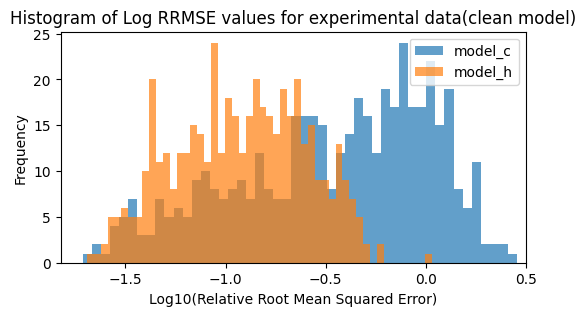

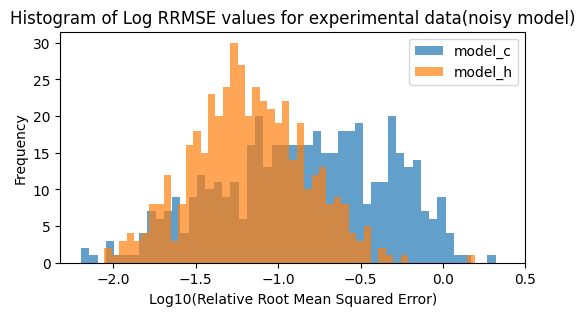

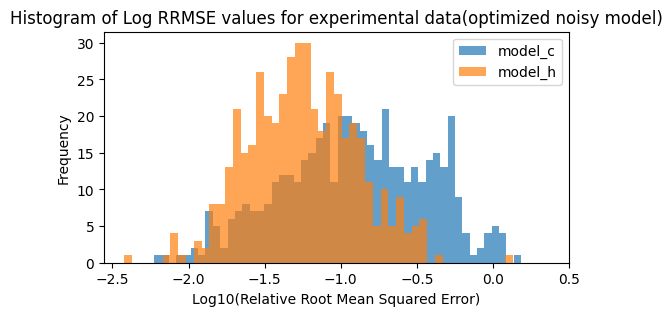

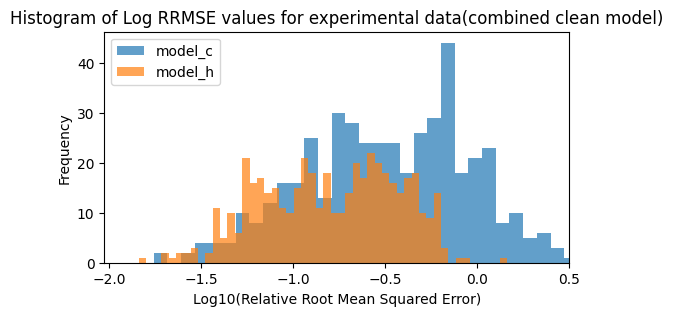

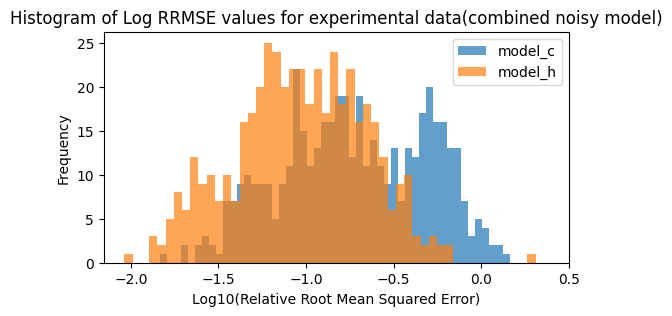

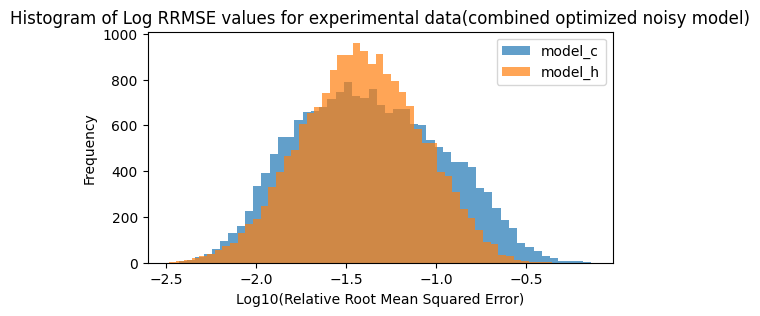

In [159]:
# Prepare the test data
X_test_expr = I_scaled_interp.astype(np.float32)
y_test_c_calculated = data_c_caluculated.astype(np.float32)
y_test_h_calculated = data_h_calculated.astype(np.float32)

# Use trained models to make predictions
predictions_c_calculated_clean = model_c_clean.predict(X_test_expr)
predictions_h_calculated_clean = model_h_clean.predict(X_test_expr)

predictions_c_calculated_noisy = model_c_noisy.predict(X_test_expr)
predictions_h_calculated_noisy = model_h_noisy.predict(X_test_expr)

predictions_c_calculated_noisy_opt = model_c_noisy_opt.predict(X_test_expr)
predictions_h_calculated_noisy_opt = model_h_noisy_opt.predict(X_test_expr)

predictions_combined_clean = model_combined_clean.predict(X_test_expr)
predictions_c_combined_clean = 1/(predictions_combined_clean[:, :601] + 1e-14)  # Extracting the first 601 columns for c predictions
predictions_h_combined_clean = predictions_combined_clean[:, 601:]  # Extracting the last 601 columns for h predictions

predictions_combined_noisy = model_combined_noisy.predict(X_test_expr)
predictions_c_combined_noisy = 1/(predictions_combined_noisy[:, :601] + 1e-14)  # Extracting the first 601 columns for c predictions
predictions_h_combined_noisy = predictions_combined_noisy[:, 601:]  # Extracting the last 601 columns for h predictions

predictions_combined_noisy_opt = model_combined_noisy_opt.predict(X_test_expr)
predictions_c_combined_noisy_opt = 1/(predictions_combined_noisy_opt[:, :601] + 1e-14)  # Extracting the first 601 columns for c predictions
predictions_h_combined_noisy_opt = predictions_combined_noisy_opt[:, 601:]  # Extracting the last 601 columns for h predictions

# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_calculated_clean = np.sqrt(np.sum((predictions_c_calculated_clean - y_test_c_calculated) ** 2, axis=1) / np.sum(y_test_c_calculated ** 2, axis=1))
rrmse_h_calculated_clean = np.sqrt(np.sum((predictions_h_calculated_clean - y_test_h_calculated) ** 2, axis=1) / np.sum(y_test_h_calculated ** 2, axis=1))

rrmse_c_calculated_noisy = np.sqrt(np.sum((predictions_c_calculated_noisy - y_test_c_calculated) ** 2, axis=1) / np.sum(y_test_c_calculated ** 2, axis=1))
rrmse_h_calculated_noisy = np.sqrt(np.sum((predictions_h_calculated_noisy - y_test_h_calculated) ** 2, axis=1) / np.sum(y_test_h_calculated ** 2, axis=1))

rrmse_c_calculated_noisy_opt = np.sqrt(np.sum((predictions_c_calculated_noisy_opt - y_test_c_calculated) ** 2, axis=1) / np.sum(y_test_c_calculated ** 2, axis=1))
rrmse_h_calculated_noisy_opt = np.sqrt(np.sum((predictions_h_calculated_noisy_opt - y_test_h_calculated) ** 2, axis=1) / np.sum(y_test_h_calculated ** 2, axis=1))

rrmse_c_combined_clean = np.sqrt(np.sum((predictions_c_combined_clean - y_test_c_calculated) ** 2, axis=1) / np.sum(y_test_c_calculated ** 2, axis=1))
rrmse_h_combined_clean = np.sqrt(np.sum((predictions_h_combined_clean - y_test_h_calculated) ** 2, axis=1) / np.sum(y_test_h_calculated ** 2, axis=1))

rrmse_c_combined_noisy = np.sqrt(np.sum((predictions_c_combined_noisy - y_test_c_calculated) ** 2, axis=1) / np.sum(y_test_c_calculated ** 2, axis=1))
rrmse_h_combined_noisy = np.sqrt(np.sum((predictions_h_combined_noisy - y_test_h_calculated) ** 2, axis=1) / np.sum(y_test_h_calculated ** 2, axis=1))

rrmse_c_calculated_noisy_opt = np.sqrt(np.sum((predictions_c_calculated_noisy_opt - y_test_c_calculated) ** 2, axis=1) / np.sum(y_test_c_calculated ** 2, axis=1))
rrmse_h_calculated_noisy_opt = np.sqrt(np.sum((predictions_h_calculated_noisy_opt - y_test_h_calculated) ** 2, axis=1) / np.sum(y_test_h_calculated ** 2, axis=1))

print("Experimental RMSE for model_c_clean:", np.mean(rrmse_c_calculated_clean))
print("Experimental RMSE for model_h_clean:", np.mean(rrmse_h_calculated_clean))
print("Experimental RMSE for model_c_noisy:", np.mean(rrmse_c_calculated_noisy))
print("Experimental RMSE for model_h_noisy:", np.mean(rrmse_h_calculated_noisy))
print("Experimental RMSE for model_c_noisy_opt:", np.mean(rrmse_c_calculated_noisy_opt))
print("Experimental RMSE for model_h_noisy_opt:", np.mean(rrmse_h_calculated_noisy_opt))
print("Experimental RMSE for combined model_c_clean:", np.mean(rrmse_c_combined_clean))
print("Experimental RMSE for combined model_h_clean:", np.mean(rrmse_h_combined_clean))
print("Experimental RMSE for combined model_c_noisy:", np.mean(rrmse_c_combined_noisy))
print("Experimental RMSE for combined model_h_noisy:", np.mean(rrmse_h_combined_noisy))
print("Experimental RMSE for combined model_c_noisy_opt:", np.mean(rrmse_c_calculated_noisy_opt))
print("Experimental RMSE for combined model_h_noisy_opt:", np.mean(rrmse_h_calculated_noisy_opt))

# Log-scale histogram
plt.figure(figsize=(6,3))
plt.hist(np.log10(rrmse_c_calculated_clean), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_calculated_clean), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values for experimental data(clean model)')
plt.legend()
plt.xlim(left=None, right=0.5)  # Set the x-axis limit to not go beyond 0.5
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_expr_clean.png", dpi=300)
plt.show()

plt.figure(figsize=(6,3))
plt.hist(np.log10(rrmse_c_calculated_noisy), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_calculated_noisy), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values for experimental data(noisy model)')
plt.legend()
plt.xlim(left=None, right=0.5)  # Set the x-axis limit to not go beyond 0.5
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_expr_noisy.png", dpi=300)
plt.show()

plt.figure(figsize=(6,3))
plt.hist(np.log10(rrmse_c_calculated_noisy_opt), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_calculated_noisy_opt), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values for experimental data(optimized noisy model)')
plt.legend()
plt.xlim(left=None, right=0.5)  # Set the x-axis limit to not go beyond 0.5
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_expr_noisy_opt.png", dpi=300)
plt.show()

plt.figure(figsize=(6,3))
plt.hist(np.log10(rrmse_c_combined_clean), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_combined_clean), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values for experimental data(combined clean model)')
plt.legend()
plt.xlim(left=None, right=0.5)  # Set the x-axis limit to not go beyond 0.5
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_expr_combined_clean.png", dpi=300)
plt.show()

plt.figure(figsize=(6,3))
plt.hist(np.log10(rrmse_c_combined_noisy), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_combined_noisy), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values for experimental data(combined noisy model)')
plt.legend()
plt.xlim(left=None, right=0.5)  # Set the x-axis limit to not go beyond 0.5
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_expr_combined_noisy.png", dpi=300)
plt.show()

plt.figure(figsize=(6,3))
plt.hist(np.log10(rrmse_c_combined_noisy_opt), bins=50, alpha=0.7, label='model_c')
plt.hist(np.log10(rrmse_h_combined_noisy_opt), bins=50, alpha=0.7, label='model_h')
plt.xlabel('Log10(Relative Root Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RRMSE values for experimental data(combined optimized noisy model)')
plt.legend()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/histograms/hist_expr_combined_noisy_opt.png", dpi=300)
plt.show()

438


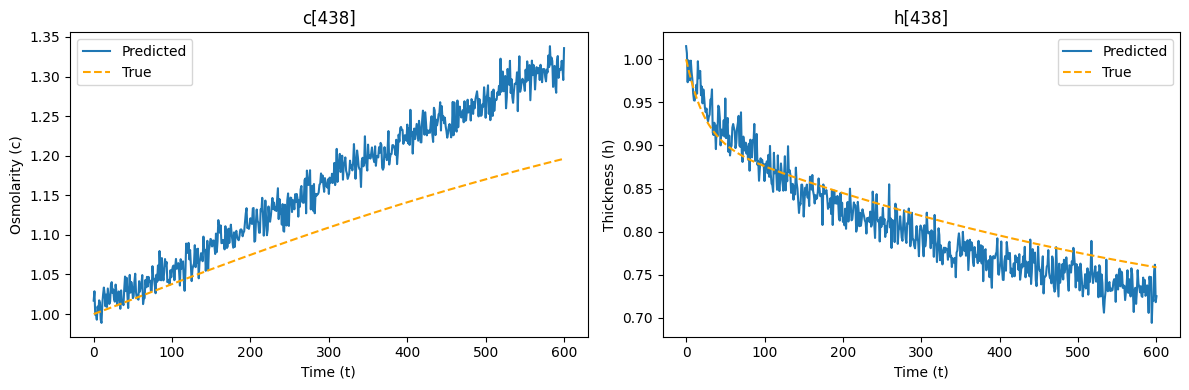

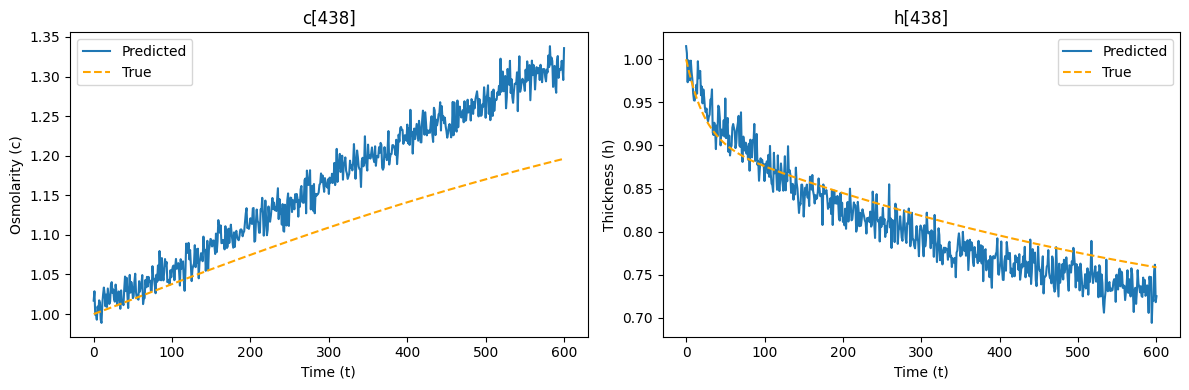

In [160]:
n = np.random.randint(0, len(X_test_expr))
print(n)
pred_c_clean = model_c_clean.predict(X_test_expr[n].reshape(1, -1))
pred_h_clean = model_h_clean.predict(X_test_expr[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c_clean.T)
axs[0].plot(y_test_c_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_clean.T)
axs[1].plot(y_test_h_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns
# Plot data_c[n]
axs[0].plot(pred_c_clean.T)
axs[0].plot(y_test_c_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h_clean.T)
axs[1].plot(y_test_h_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()


In [161]:
# Calculate predictions for f from predictions_c_calculated and f_0
# f_0 is the fifth entry of data_p_experimental_nondimensional (index 4)
f_0_experimental = data_p_experimental_nondimensional[:, 4]  # shape: (num_samples,)

# predictions_c_calculated shape: (num_samples, 601)
# We want to multiply each row of predictions_c_calculated by the corresponding f_0
predictions_f_calculated_clean = predictions_c_calculated_clean * f_0_experimental[:, np.newaxis]

predictions_f_calculated_noisy = predictions_c_calculated_noisy * f_0_experimental[:, np.newaxis]


In [162]:
def calculate_I(h, f, phi, I_0=1.0):
    return I_0 * (1 - np.exp(-phi * h * f)) / (1 + f ** 2)

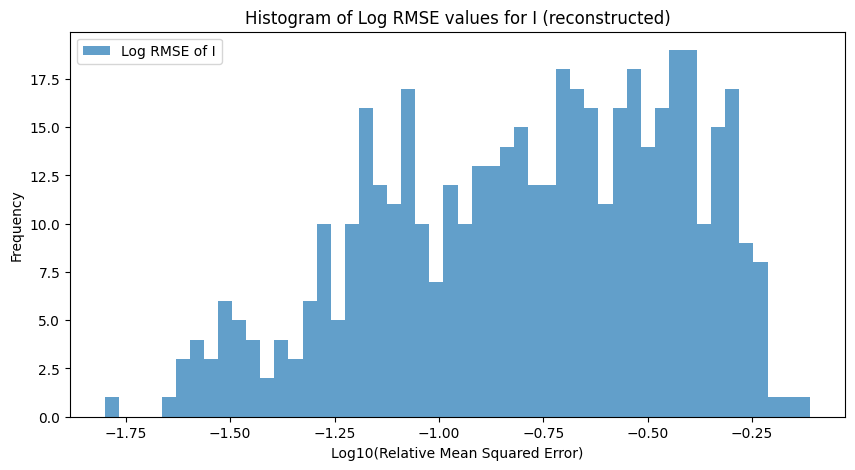

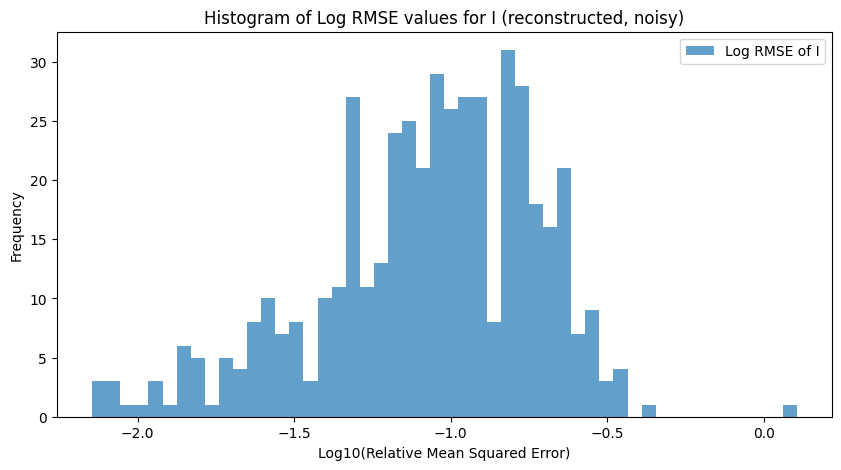

In [163]:
# Ensure phi is broadcastable to shape (num_samples, 601)
phi_expanded = data_p_experimental_nondimensional[:, 6][:, np.newaxis]  # shape: (num_samples, 1)

# Calculate I_pred using predictions_h_calculated and predictions_f_calculated
I_0_pred_clean = 1/calculate_I(predictions_h_calculated_clean[:,0].reshape(phi_expanded.shape), predictions_f_calculated_clean[:,0].reshape(phi_expanded.shape), phi=phi_expanded)
I_pred_clean = calculate_I(predictions_h_calculated_clean, predictions_f_calculated_clean, phi=phi_expanded, I_0=I_0_pred_clean)

I_0_pred_noisy = 1/calculate_I(predictions_h_calculated_noisy[:,0].reshape(phi_expanded.shape), predictions_f_calculated_noisy[:,0].reshape(phi_expanded.shape), phi=phi_expanded)
I_pred_noisy = calculate_I(predictions_h_calculated_noisy, predictions_f_calculated_noisy, phi=phi_expanded, I_0=I_0_pred_noisy)

# Compute relative MSE for each sample
rel_mse_I_clean = np.sqrt(np.sum((I_pred_clean - data_I_calculated) ** 2, axis=1) / np.sum(data_I_calculated ** 2, axis=1))
rel_mse_I_noisy = np.sqrt(np.sum((I_pred_noisy - data_I_calculated) ** 2, axis=1) / np.sum(data_I_calculated ** 2, axis=1))

# Plot histogram of log10(relative MSE)
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rel_mse_I_clean), bins=50, alpha=0.7, label='Log RMSE of I')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for I (reconstructed)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10(rel_mse_I_noisy), bins=50, alpha=0.7, label='Log RMSE of I')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for I (reconstructed, noisy)')
plt.legend()
plt.show()

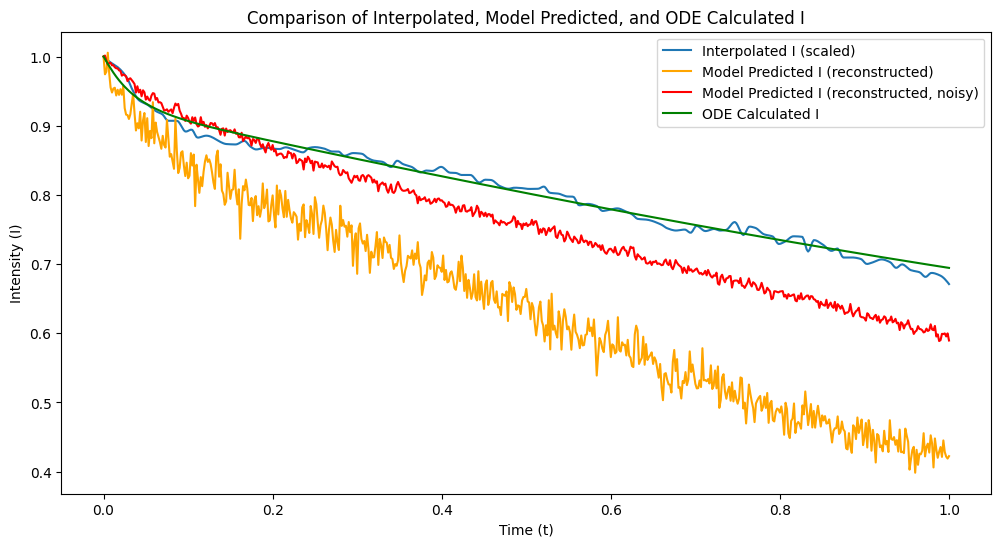

In [164]:
n = np.random.randint(0, len(I_scaled_interp))

plt.figure(figsize=(12, 6))
plt.plot(t_scaled_interp[n], I_scaled_interp[n], label='Interpolated I (scaled)')
plt.plot(t_scaled_interp[n], I_pred_clean[n], color='orange', label='Model Predicted I (reconstructed)')
plt.plot(t_scaled_interp[n], I_pred_noisy[n], color='red', label='Model Predicted I (reconstructed, noisy)')
plt.plot(t_scaled_interp[n], data_I_calculated[n], color='green', label='ODE Calculated I')
plt.xlabel('Time (t)')
plt.ylabel('Intensity (I)')
plt.title('Comparison of Interpolated, Model Predicted, and ODE Calculated I')
plt.legend()
plt.show()

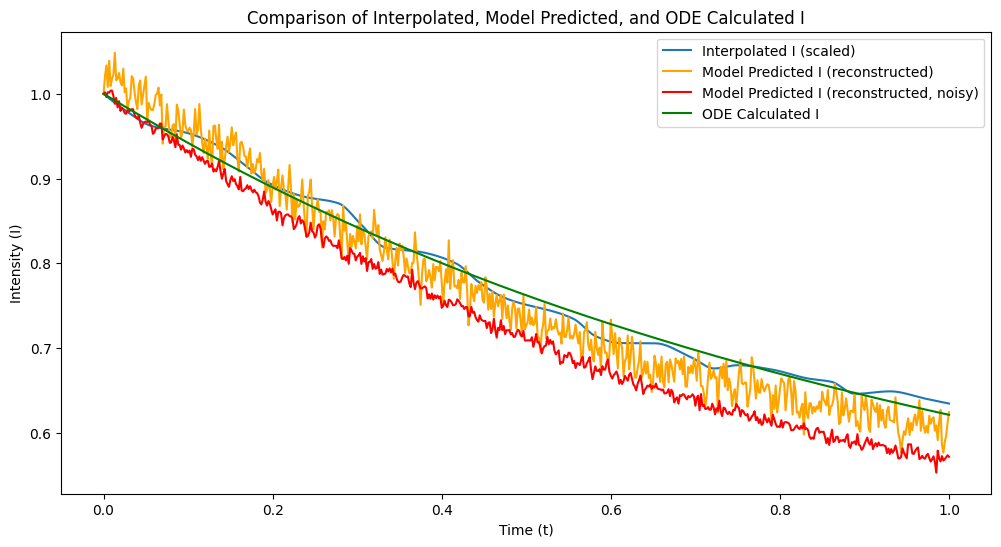

In [165]:
n = np.random.randint(0, len(I_scaled_interp))

plt.figure(figsize=(12, 6))
plt.plot(t_scaled_interp[n], I_scaled_interp[n], label='Interpolated I (scaled)')
plt.plot(t_scaled_interp[n], I_pred_clean[n], color='orange', label='Model Predicted I (reconstructed)')
plt.plot(t_scaled_interp[n], I_pred_noisy[n], color='red', label='Model Predicted I (reconstructed, noisy)')
plt.plot(t_scaled_interp[n], data_I_calculated[n], color='green', label='ODE Calculated I')
plt.xlabel('Time (t)')
plt.ylabel('Intensity (I)')
plt.title('Comparison of Interpolated, Model Predicted, and ODE Calculated I')
plt.legend()
plt.show()

In [166]:
# import os

# # Path where plots will be stored
# plot_dir_h = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/h_plots"
# plot_dir_c = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/c_plots"
# plot_dir_f = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/f_plots"
# plot_dir_I = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/I_plots"
# os.makedirs(plot_dir_h, exist_ok=True)  # Create the folder if it doesn't exist
# os.makedirs(plot_dir_c, exist_ok=True)  # Create the folder if it doesn't exist
# os.makedirs(plot_dir_I, exist_ok=True)  # Create the folder if it doesn't exist
# os.makedirs(plot_dir_f, exist_ok=True)  # Create the folder if it doesn't exist

# # Loop through all 467 samples
# for idx in range(467):
#     # Get data for this sample (already loaded in your variables)
#     id = id_array[idx]
#     t = t_scaled_interp[idx]
#     I_exp = I_scaled_interp[idx]
#     h_true = data_h_calculated[idx]
#     c_true = data_c_caluculated[idx]
#     f_true = data_f_calculated[idx]
    
#     I_pred_n = I_pred[idx]
#     h_pred = predictions_h_calculated[idx]
#     c_pred = predictions_c_calculated[idx]
#     f_pred = predictions_f_calculated[idx]
    
#     I_ode = data_I_calculated[idx]
    
#     fig1, ax1 = plt.subplots()
#     ax1.plot(t, I_exp, label='Experimental I (scaled)')
#     ax1.plot(t, I_pred_n, label='Model Predicted I (reconstructed)')
#     ax1.plot(t, I_ode, color='green', label='ODE Calculated I')
#     ax1.set_title(f'I for Sample {id}')
#     ax1.set_xlabel('Time Index')
#     ax1.set_ylabel('I')
#     ax1.legend()
#     fig1.tight_layout()
#     fig1.savefig(f"{plot_dir_I}/I_{id}.png")
#     plt.close(fig1)

#     fig2, ax2 = plt.subplots()
#     ax2.plot(t, h_true, label='ODE calculated h')
#     ax2.plot(t, h_pred, label='Model Predicted h')
#     ax2.set_title(f'h for Sample {id}')
#     ax2.set_xlabel('Time Index')
#     ax2.set_ylabel('h')
#     ax2.legend()
#     fig2.tight_layout()
#     fig2.savefig(f"{plot_dir_h}/h_{id}.png")
#     plt.close(fig2)
    
#     fig3, ax3 = plt.subplots()
#     ax3.plot(t, c_true, label='ODE calculated c')
#     ax3.plot(t, c_pred, label='Model Predicted c')
#     ax3.set_title(f'c for Sample {id}')
#     ax3.set_xlabel('Time Index')
#     ax3.set_ylabel('c')
#     ax3.legend()
#     fig3.tight_layout()
#     fig3.savefig(f"{plot_dir_c}/c_{id}.png")
#     plt.close(fig3)
    
#     fig4, ax4 = plt.subplots()
#     ax4.plot(t, f_true, label='ODE calculated f')
#     ax4.plot(t, f_pred, label='Model Predicted f')
#     ax4.set_title(f'f for Sample {id}')
#     ax4.set_xlabel('Time Index')
#     ax4.set_ylabel('f')
#     ax4.legend()
#     fig4.tight_layout()
#     fig4.savefig(f"{plot_dir_f}/f_{id}.png")
#     plt.close(fig4)


# Error Analysis

In [176]:
# data_p = np.array(np.array(datastore["parameters: J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts"]))#[:40000]

data_p_train = data_p[train_label]
data_p_test = data_p[test_label]

ts_train = data_p_train[:, 8]  # ts for training set
ts_test = data_p_test[:, 8]  # ts for testing set

h0_train = data_p_train[:, 7]  # h0 for training set
h0_test = data_p_test[:, 7]  # h0 for testing set

J_e_train = data_p_train[:, 0]  # J_e for training set
J_e_test = data_p_test[:, 0]  # J_e for testing set

b_1_train = data_p_train[:, 1]  # b_1 for training set
b_1_test = data_p_test[:, 1]  # b_1 for testing set 

b_2_train = data_p_train[:, 2]  # b_2 for training set
b_2_test = data_p_test[:, 2]  # b_2 for testing set

Pc_train = data_p_train[:, 5]  # Pc for training set
Pc_test = data_p_test[:, 5]  # Pc for testing set

phi_train = data_p_train[:, 6]  # phi for training set
phi_test = data_p_test[:, 6]  # phi for testing set

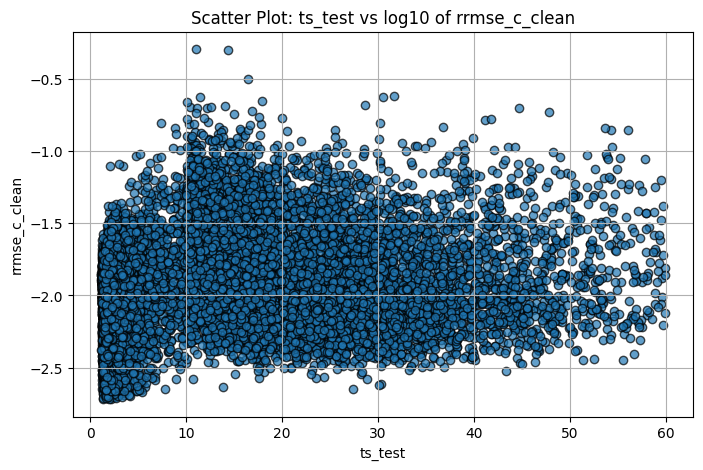

In [177]:
plt.figure(figsize=(8, 5))
plt.scatter(ts_test, np.log10(rrmse_c_clean), alpha=0.7, edgecolors='k')

plt.xlabel("ts_test")
plt.ylabel("rrmse_c_clean")
plt.title("Scatter Plot: ts_test vs log10 of rrmse_c_clean")
plt.grid(True)

plt.show()

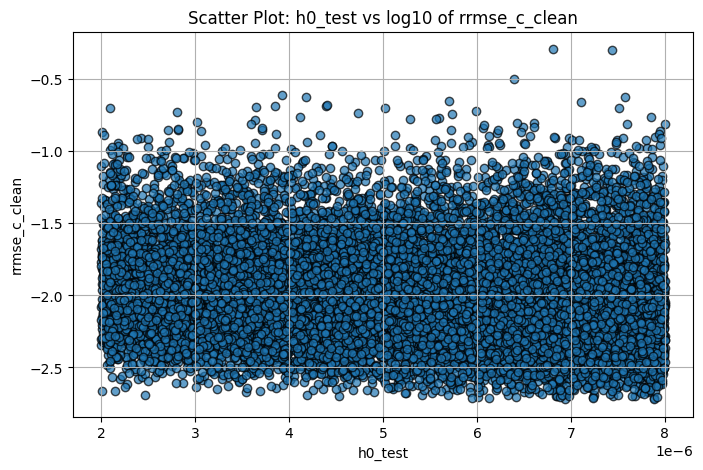

In [178]:
plt.figure(figsize=(8, 5))
plt.scatter(h0_test, np.log10(rrmse_c_clean), alpha=0.7, edgecolors='k')

plt.xlabel("h0_test")
plt.ylabel("rrmse_c_clean")
plt.title("Scatter Plot: h0_test vs log10 of rrmse_c_clean")
plt.grid(True)

plt.show()

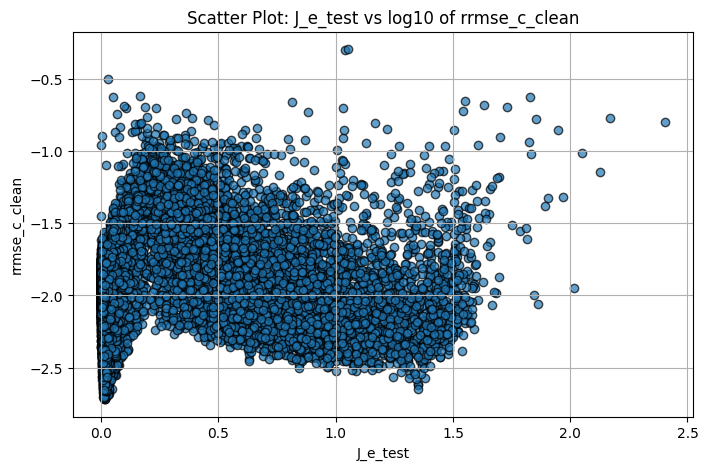

In [179]:
plt.figure(figsize=(8, 5))
plt.scatter(J_e_test, np.log10(rrmse_c_clean), alpha=0.7, edgecolors='k')

plt.xlabel("J_e_test")
plt.ylabel("rrmse_c_clean")
plt.title("Scatter Plot: J_e_test vs log10 of rrmse_c_clean")
plt.grid(True)
plt.show()

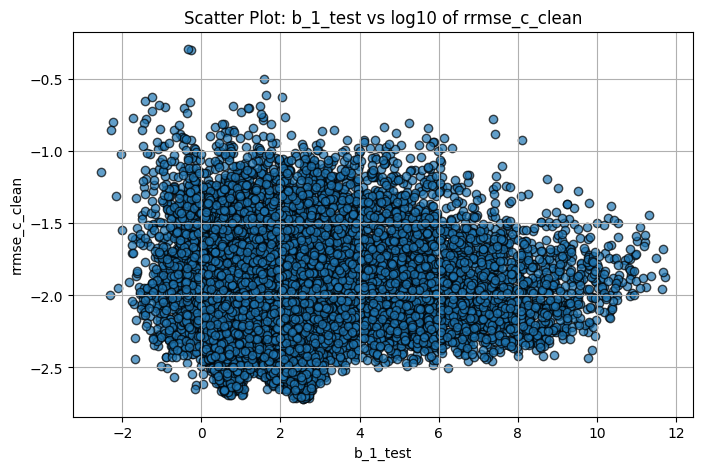

In [180]:
plt.figure(figsize=(8, 5))
plt.scatter(b_1_test, np.log10(rrmse_c_clean), alpha=0.7, edgecolors='k')

plt.xlabel("b_1_test")
plt.ylabel("rrmse_c_clean")
plt.title("Scatter Plot: b_1_test vs log10 of rrmse_c_clean")
plt.grid(True)
plt.show()

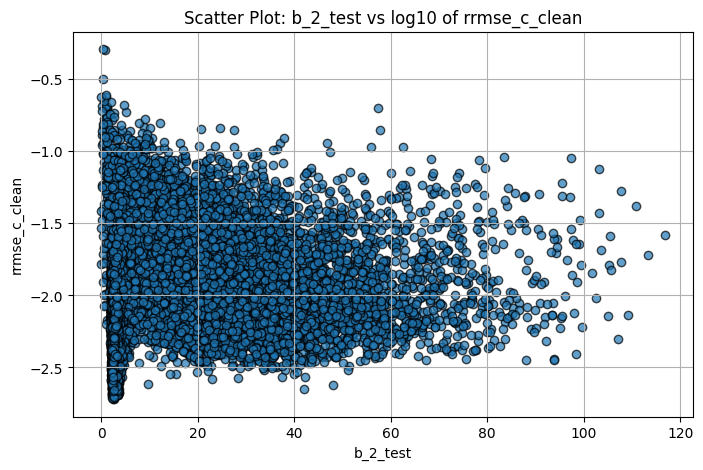

In [181]:
plt.figure(figsize=(8, 5))
plt.scatter(b_2_test, np.log10(rrmse_c_clean), alpha=0.7, edgecolors='k')

plt.xlabel("b_2_test")
plt.ylabel("rrmse_c_clean")
plt.title("Scatter Plot: b_2_test vs log10 of rrmse_c_clean")
plt.grid(True)
plt.show()

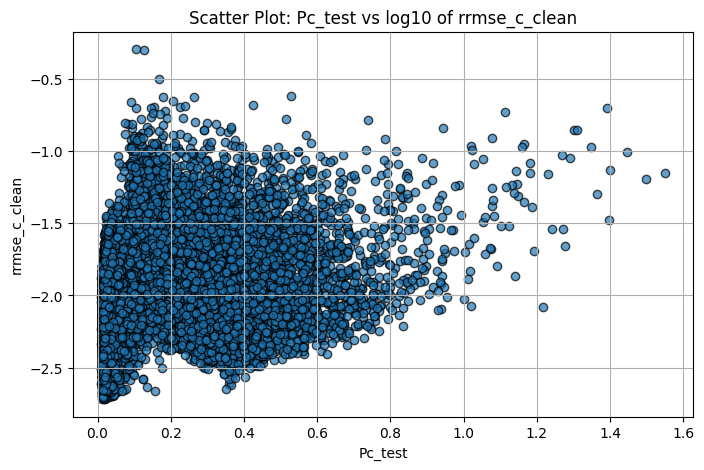

In [182]:
plt.figure(figsize=(8, 5))
plt.scatter(Pc_test, np.log10(rrmse_c_clean), alpha=0.7, edgecolors='k')

plt.xlabel("Pc_test")
plt.ylabel("rrmse_c_clean")
plt.title("Scatter Plot: Pc_test vs log10 of rrmse_c_clean")
plt.grid(True)
plt.show()

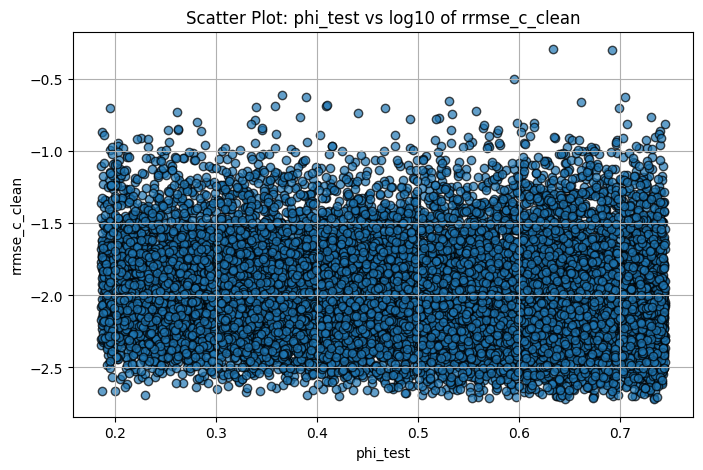

In [183]:
plt.figure(figsize=(8, 5))
plt.scatter(phi_test, np.log10(rrmse_c_clean), alpha=0.7, edgecolors='k')
plt.xlabel("phi_test")
plt.ylabel("rrmse_c_clean")
plt.title("Scatter Plot: phi_test vs log10 of rrmse_c_clean")
plt.grid(True)
plt.show()

In [184]:
ts_glob = para_glob[:, 0]  # ts for training set
h0_glob = para_glob[:, 1]  # h0 for training set
f0_glob = para_glob[:, 2]  # f_0 for training set
d_sigma_0_glob = para_glob[:, 3]  # d_sigma_0 for training set
RI_glob = para_glob[:, 4]  # RI for training set
J_e_glob = para_glob[:, 5]  # J_e for training set

print(ts_glob.shape, h0_glob.shape, f0_glob.shape, d_sigma_0_glob.shape, RI_glob.shape, J_e_glob.shape, rrmse_c_glob_clean.shape, rrmse_h_glob_clean.shape)

NameError: name 'para_glob' is not defined

In [ ]:
# plt.figure(figsize=(8, 5))
# plt.scatter(ts_glob, np.log10(rrmse_c_glob_clean), alpha=0.7, edgecolors='k')

# plt.xlabel("ts_glob_test")
# plt.ylabel("rrmse_c_glob_clean")
# plt.title("Scatter Plot: ts_test vs log10 of rrmse_c_clean")
# plt.grid(True)

# plt.show()

In [185]:
ts_exp = data_p_experimental_nondimensional[:, 8]  # ts for experimental set
h0_exp = data_p_experimental_nondimensional[:, 7]  # h0 for experimental set
J_e_exp = data_p_experimental_nondimensional[:, 0]  # J_e for experimental set
b_1_exp = data_p_experimental_nondimensional[:, 1]  # b_1 for experimental set
b_2_exp = data_p_experimental_nondimensional[:, 2]  # b_2 for experimental set
Pc_exp = data_p_experimental_nondimensional[:, 5]  # Pc for experimental set
phi_exp = data_p_experimental_nondimensional[:, 6]  # phi for experimental set

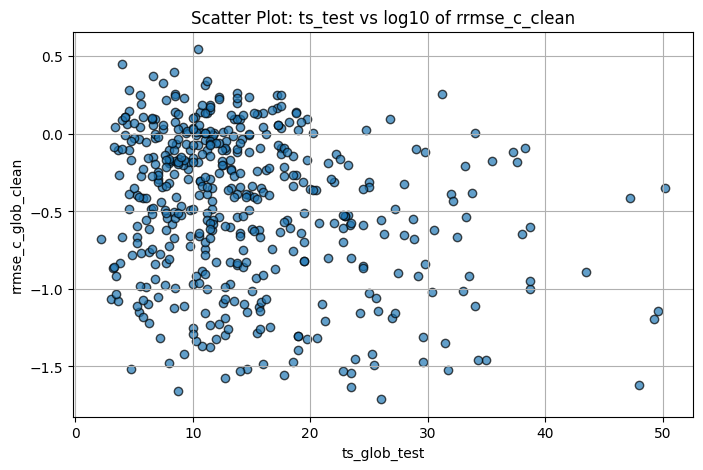

In [186]:
plt.figure(figsize=(8, 5))
plt.scatter(ts_exp, np.log10(rrmse_c_calculated_clean), alpha=0.7, edgecolors='k')

plt.xlabel("ts_glob_test")
plt.ylabel("rrmse_c_glob_clean")
plt.title("Scatter Plot: ts_test vs log10 of rrmse_c_clean")
plt.grid(True)

plt.show()

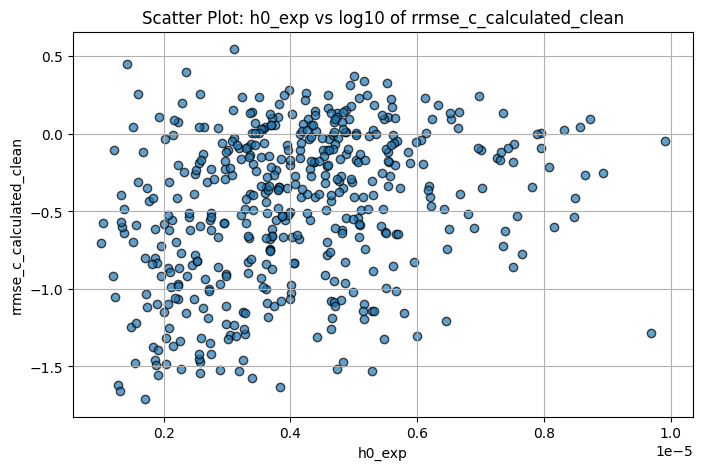

In [187]:
plt.figure(figsize=(8, 5))
plt.scatter(h0_exp, np.log10(rrmse_c_calculated_clean), alpha= 0.7, edgecolors='k')
plt.xlabel("h0_exp")
plt.ylabel("rrmse_c_calculated_clean")
plt.title("Scatter Plot: h0_exp vs log10 of rrmse_c_calculated_clean")
plt.grid(True)
plt.show()

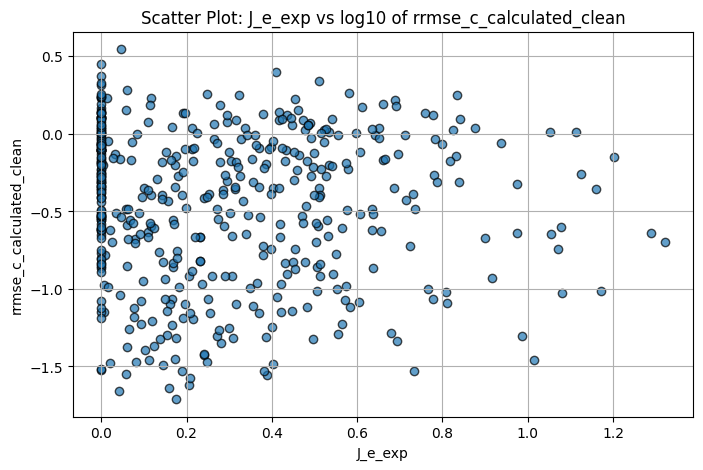

In [188]:
plt.figure(figsize=(8, 5))
plt.scatter(J_e_exp, np.log10(rrmse_c_calculated_clean), alpha=0.7, edgecolors='k')
plt.xlabel("J_e_exp")
plt.ylabel("rrmse_c_calculated_clean")
plt.title("Scatter Plot: J_e_exp vs log10 of rrmse_c_calculated_clean")
plt.grid(True)
plt.show()

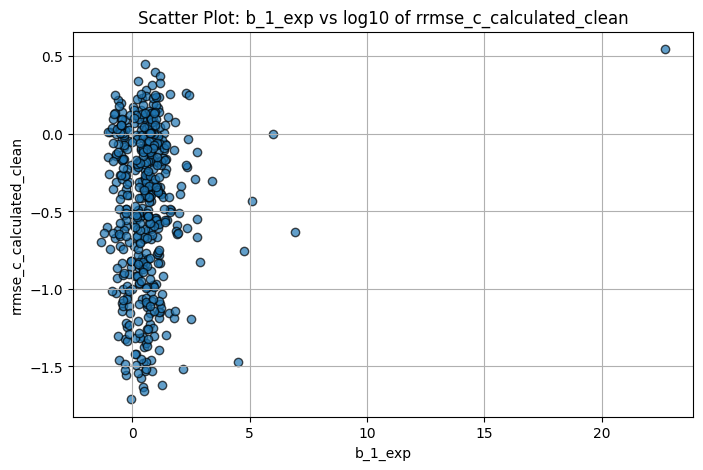

In [189]:
plt.figure(figsize=(8, 5))
plt.scatter(b_1_exp, np.log10(rrmse_c_calculated_clean), alpha=0.7, edgecolors='k')
plt.xlabel("b_1_exp")
plt.ylabel("rrmse_c_calculated_clean")
plt.title("Scatter Plot: b_1_exp vs log10 of rrmse_c_calculated_clean")
plt.grid(True)
plt.show()

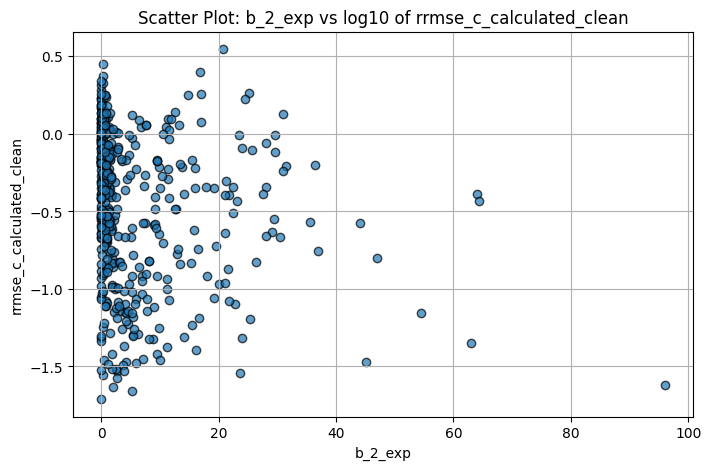

In [190]:
plt.figure(figsize=(8, 5))
plt.scatter(b_2_exp, np.log10(rrmse_c_calculated_clean), alpha=0.7, edgecolors='k')
plt.xlabel("b_2_exp")
plt.ylabel("rrmse_c_calculated_clean")
plt.title("Scatter Plot: b_2_exp vs log10 of rrmse_c_calculated_clean")
plt.grid(True)
plt.show()

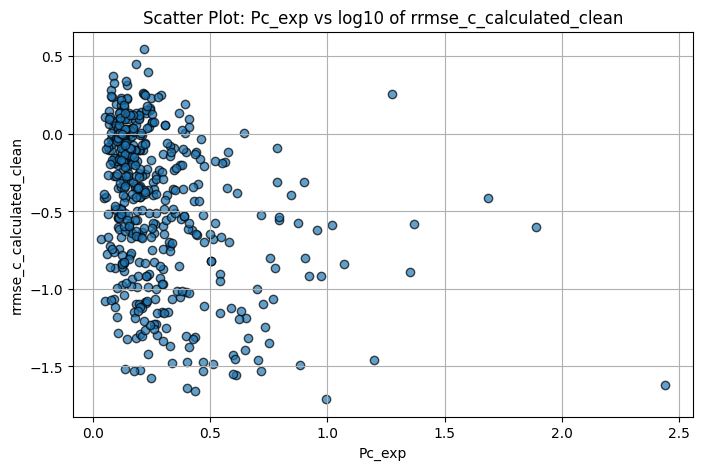

In [191]:
plt.figure(figsize=(8, 5))
plt.scatter(Pc_exp, np.log10(rrmse_c_calculated_clean), alpha=0.7, edgecolors='k')
plt.xlabel("Pc_exp")
plt.ylabel("rrmse_c_calculated_clean")
plt.title("Scatter Plot: Pc_exp vs log10 of rrmse_c_calculated_clean")
plt.grid(True)
plt.show()

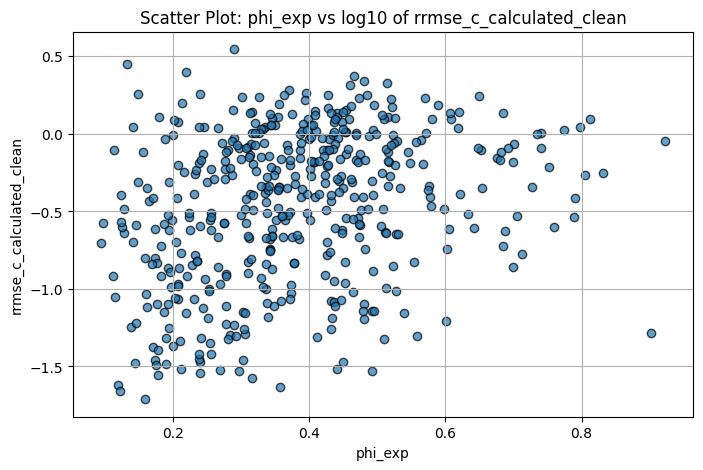

In [192]:
plt.figure(figsize=(8, 5))
plt.scatter(phi_exp, np.log10(rrmse_c_calculated_clean), alpha=0.7, edgecolors='k')
plt.xlabel("phi_exp")
plt.ylabel("rrmse_c_calculated_clean")
plt.title("Scatter Plot: phi_exp vs log10 of rrmse_c_calculated_clean")
plt.grid(True)
plt.show()